<a href="https://colab.research.google.com/github/GeorgeShmelin/Text-Recognition/blob/MS_mini_project/Project_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Forecasting Currency Exchange Rates for Banking Operations

This short study focuses on forecasting the exchange rates of the Chinese Renminbi (CNY) and the Singapore Dollar (SGD) against the US Dollar (USD) over the next three months. For this purpose, a relatively simple and computationally efficient SARIMAX model was employed.

Initial analysis revealed that the People’s Bank of China (PBoC) maintained an artificially low value for the Renminbi until approximately 2012. Only following the partial liberalisation of the currency did it begin to reflect market forces, behaving more like a neural network adjusting dynamically to real economic inputs (all relevant academic and commercial references are provided below). Consequently, for reliable forecasting purposes, only data from post-summer 2016 was deemed suitable for model training and evaluation—albeit with caution.

Both empirical results and existing literature suggest that the value of the Singapore Dollar is heavily influenced by movements in the Chinese Renminbi. Accordingly, the SARIMAX model for predicting the SGD was designed with approximately 80% of its explanatory power attributed to the CNY, and only 20% to other economic partners of Singapore. Given Singapore’s relatively small yet affluent economy, which is predominantly banking-oriented, and its close trade ties with China, this assumption is justified.

Seasonal patterns were also observed: the Renminbi tends to appreciate throughout the year as China exports large volumes of low-cost goods to the United States. However, during late summer, the CNY typically weakens as China begins large-scale imports of soybeans (in August) and crude oil and gas (in late August to early November) from the US. These trade dynamics drive temporary increases in the USD’s value relative to the CNY.

The SARIMAX model was able to forecast the value of the Renminbi over the upcoming three-month period with a mean absolute percentage error (MAPE) of approximately 0.67%. Based on this forecast, the SGD was subsequently predicted, yielding a MAPE of around 2.2%—a level of accuracy consistent with similar approaches found in the literature.

As an alternative modelling strategy, I attempted to invert the approach—first predicting the SGD and then inferring the CNY based on its historical correlation. However, this reverse model proved unsuccessful. The inverse relationship appeared too complex to capture accurately without either significantly more data (e.g., on soybean and oil prices) or a far more computationally intensive modelling framework.

Further research into both modelling directions is ongoing.

# Libraries

## general

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import gc
# gc.collect() are for rubbish collection

## modeling

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

### Darts

In [ ]:
#!pip install darts

In [ ]:
#pip install u8darts[all]

In [ ]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import NBEATSModel
from darts.metrics import mape
from darts.models import ExponentialSmoothing

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7fdeab1e32e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


In [ ]:
#!pip install --no-cache-dir --upgrade numpy==1.26.4 pmdarima

In [ ]:
#!pip uninstall -y numpy pmdarima
#!pip install numpy==1.26.4
#!pip install pmdarima

In [ ]:
import pmdarima
from pmdarima import auto_arima

--------------------------------------------------------------------------------


# Data

## download

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_or = pd.read_csv('/content/drive/MyDrive/MasterSchool/Project/Foreign_Exchange_Rates.csv', sep=';')

In [ ]:
df_or.shape

(5217, 3)

In [ ]:
df_or.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 3 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   DATE                              5217 non-null   object
 1   SINGAPORE - SINGAPORE DOLLAR/US$  5217 non-null   object
 2   CHINA - YUAN/US$                  5217 non-null   object
dtypes: object(3)
memory usage: 122.4+ KB


In [ ]:
df_or.sample(5)

,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
1863,2007-02-22,1.5335,7.7436
2778,2010-08-26,1.355,6.7998
3907,2014-12-24,1.3235,6.2148
4839,2018-07-20,1.3632,6.7659
2461,2009-06-09,1.4561,6.8353


In [ ]:
df = df_or.copy()

## initial transform

In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d', errors='coerce')

In [ ]:
print("Min date:", df['DATE'].min())
print("Max date:", df['DATE'].max())

Min date: 2000-01-03 00:00:00
Max date: 2019-12-31 00:00:00


In [ ]:
df['SINGAPORE - SINGAPORE DOLLAR/US$'] = pd.to_numeric(df['SINGAPORE - SINGAPORE DOLLAR/US$'], errors='coerce', downcast='float')

In [ ]:
print("Data type:", df['SINGAPORE - SINGAPORE DOLLAR/US$'].dtype)
print("Min SINGAPORE DOLLAR/US$:", df['SINGAPORE - SINGAPORE DOLLAR/US$'].min())
print("Max SINGAPORE DOLLAR/US$:", df['SINGAPORE - SINGAPORE DOLLAR/US$'].max())

Data type: float32
Min SINGAPORE DOLLAR/US$: 1.200700044631958
Max SINGAPORE DOLLAR/US$: 1.8539999723434448


In [ ]:
df['CHINA - YUAN/US$'] = pd.to_numeric(df['CHINA - YUAN/US$'], errors='coerce', downcast='float')

max_value = df['CHINA - YUAN/US$'].max()
max_date = df.loc[df['CHINA - YUAN/US$'] == max_value, 'DATE'].values[0]

print("Max known YUAN/US$ value:", max_value)
print("Date it occurred:", max_date)

Max known YUAN/US$ value: 8.279999732971191
Date it occurred: 2002-01-14T00:00:00.000000000


In [ ]:
print("Data type:", df['CHINA - YUAN/US$'].dtype)
print("Min YUAN/US$:", df['CHINA - YUAN/US$'].min())
print("Max YUAN/US$:", df['CHINA - YUAN/US$'].max())

Data type: float32
Min YUAN/US$: 6.040200233459473
Max YUAN/US$: 8.279999732971191


In [ ]:
print(df.dtypes)
print(df['DATE'].memory_usage(deep=True))

DATE                                datetime64[ns]
SINGAPORE - SINGAPORE DOLLAR/US$           float32
CHINA - YUAN/US$                           float32
dtype: object
41868


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 3 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   DATE                              5217 non-null   datetime64[ns]
 1   SINGAPORE - SINGAPORE DOLLAR/US$  5019 non-null   float32       
 2   CHINA - YUAN/US$                  5020 non-null   float32       
dtypes: datetime64[ns](1), float32(2)
memory usage: 81.6 KB


In [ ]:
df.isnull().sum()

,0
DATE,0
SINGAPORE - SINGAPORE DOLLAR/US$,198
CHINA - YUAN/US$,197


In [ ]:
df.set_index('DATE', inplace=True)

In [ ]:
df.head()

,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
DATE,,
2000-01-03,1.6563,8.2798
2000-01-04,1.6535,8.2799
2000-01-05,1.6560,8.2798
2000-01-06,1.6655,8.2797
2000-01-07,1.6625,8.2794


In [ ]:
gc.collect()

217

In [ ]:
df_train_test = df.copy()
df_train_test = df_train_test.loc['2012-01-01':]

df_train will contain all rows before July 1, 2019.

df_test will contain all rows from July 1, 2019 onward.

In [ ]:
df_train = df_train_test[df_train_test.index < '2019-07-01']
df_val = df_train_test[(df_train_test.index >= '2019-07-01') & (df_train_test.index < '2019-10-01')]
df_test = df_train_test[df_train_test.index >= '2019-10-01']

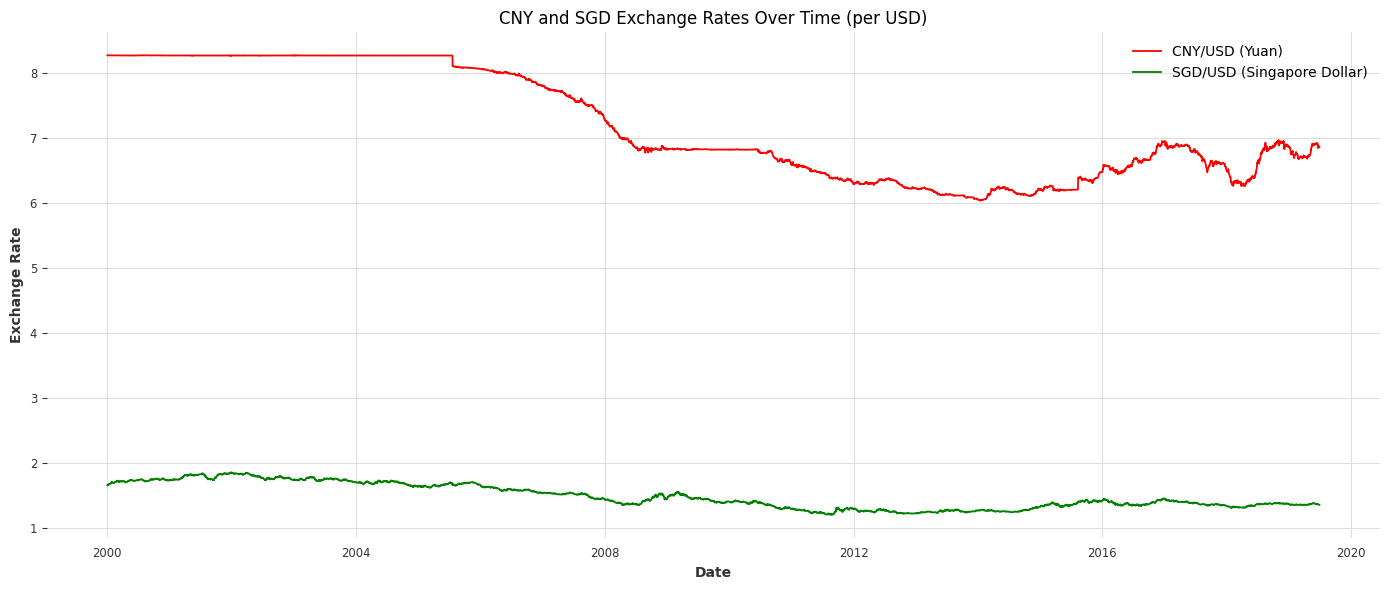

In [ ]:
df_filtered = df[df.index < '2019-07-01'][['CHINA - YUAN/US$', 'SINGAPORE - SINGAPORE DOLLAR/US$']].dropna(how='all')

plt.figure(figsize=(14, 6))
plt.plot(df_filtered.index, df_filtered['CHINA - YUAN/US$'], label='CNY/USD (Yuan)', color='red')
plt.plot(df_filtered.index, df_filtered['SINGAPORE - SINGAPORE DOLLAR/US$'], label='SGD/USD (Singapore Dollar)', color='green')

plt.title('CNY and SGD Exchange Rates Over Time (per USD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------

# Key Performance Indicators (KPIs)

I will analyse the currencies of Singapore and the People’s Republic of China (PRC) separately. The Singapore Dollar reflects a market-driven exchange rate, whereas the PRC’s currency is managed through artificial mechanisms. As such, they should be considered independently, given the fundamentally different economic factors and policy influences that shape their valuations.

In [ ]:
df_kpi = df_train.copy()
gc.collect()

3625

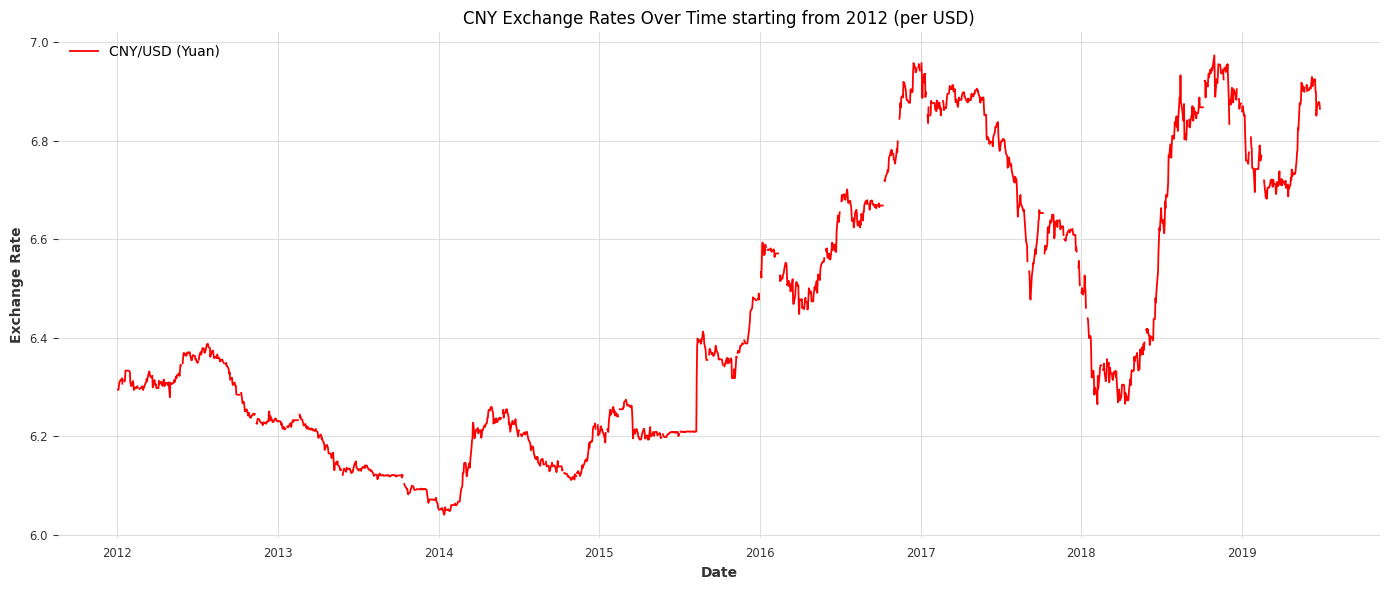

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_kpi.index, df_kpi['CHINA - YUAN/US$'], label='CNY/USD (Yuan)', color='red')

plt.title('CNY Exchange Rates Over Time starting from 2012 (per USD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

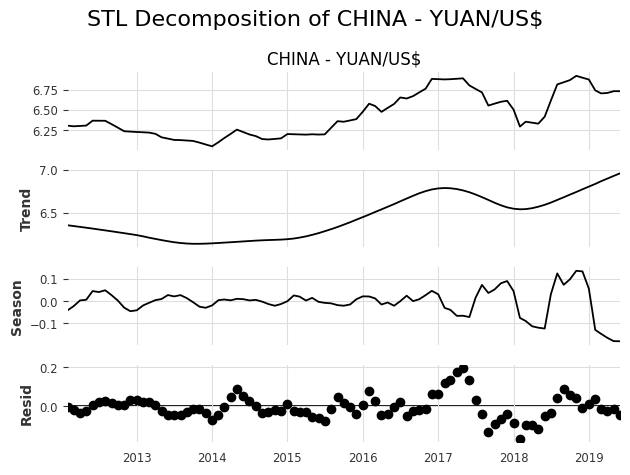

In [ ]:
df_kpi['CHINA - YUAN/US$'] = df_kpi['CHINA - YUAN/US$'].ffill().bfill()

df_kpi_monthly = df_kpi['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

if not df_kpi_monthly.empty:
    stl = STL(df_kpi_monthly, period=12)
    result = stl.fit()

    result.plot()
    plt.suptitle('STL Decomposition of CHINA - YUAN/US$', fontsize = 16)
    plt.tight_layout()
    plt.show()
else:
    print("df_kpi_monthly is empty. Cannot perform STL decomposition.")

--------------------------------------------------------------------------------

# Exploratory Data Analysis (EDA) Guidelines

## Overview of the PRC Economy and Scope of Analysis

The People’s Republic of China (PRC) is the world’s second-largest economy, characterised by rapid industrialisation, export-led growth, and increasing domestic consumption. Since initiating market-oriented reforms in the late 1970s, China has transformed from an agrarian economy into a global manufacturing and technological powerhouse. Its economic expansion has been supported by strong state involvement, extensive infrastructure investment, and a large, increasingly skilled labour force.

The Chinese renminbi (RMB), also known as the yuan, has historically been tightly managed by the People’s Bank of China (PBOC). For much of the early 2000s, the yuan was pegged to the US dollar at an artificially low rate to boost export competitiveness. While gradual liberalisation efforts began in the late 2000s, meaningful adjustments to the currency regime became more visible around 2012, including increased flexibility in the exchange rate mechanism and broader internationalisation of the RMB.

For the purpose of this analysis, I will focus on the period from 2012 onward, as prior to this, the yuan’s valuation was heavily distorted by state controls. Studying the post-2012 period allows for a more meaningful assessment of how the currency reflects underlying economic forces, relative to a gradually more market-influenced environment.

**Overview of the PRC Economy and Scope of Analysis**

The People’s Republic of China (PRC) is the world’s second-largest economy, characterised by rapid industrialisation, export-led growth, and increasing domestic consumption. Since initiating market-oriented reforms in the late 1970s, China has transformed from an agrarian economy into a global manufacturing and technological powerhouse. Its economic expansion has been supported by strong state involvement, extensive infrastructure investment, and a large, increasingly skilled labour force.

The Chinese renminbi (RMB), also known as the yuan, has historically been tightly managed by the People’s Bank of China (PBOC). For much of the early 2000s, the yuan was pegged to the US dollar at an artificially low rate to boost export competitiveness. While gradual liberalisation efforts began in the late 2000s, meaningful adjustments to the currency regime became more visible around 2012, including increased flexibility in the exchange rate mechanism and broader internationalisation of the RMB.

**For the purpose of this analysis, I will focus on the period from 2012 onward**, as prior to this, the yuan’s valuation was heavily distorted by state controls. Studying the post-2012 period allows for a more meaningful assessment of how the currency reflects underlying economic forces, relative to a gradually more market-influenced environment.

In [ ]:
df_eda = df_kpi.copy()
gc.collect()

10292

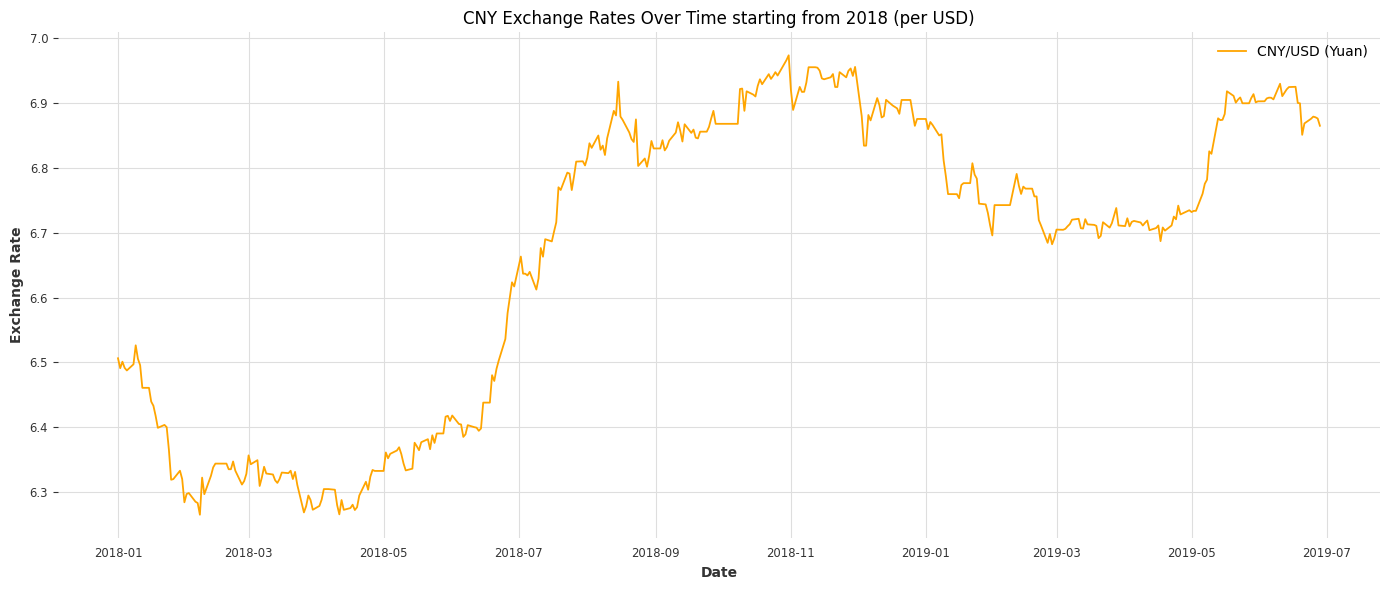

In [ ]:
df_eda_2018 = df_eda.loc['2018-01-01':]
plt.figure(figsize=(14, 6))
plt.plot(df_eda_2018.index, df_eda_2018['CHINA - YUAN/US$'], label='CNY/USD (Yuan)', color='orange')

plt.title('CNY Exchange Rates Over Time starting from 2018 (per USD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-67-2742498726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda_2018['CHINA - YUAN/US$'] = df_eda_2018['CHINA - YUAN/US$'].ffill().bfill()


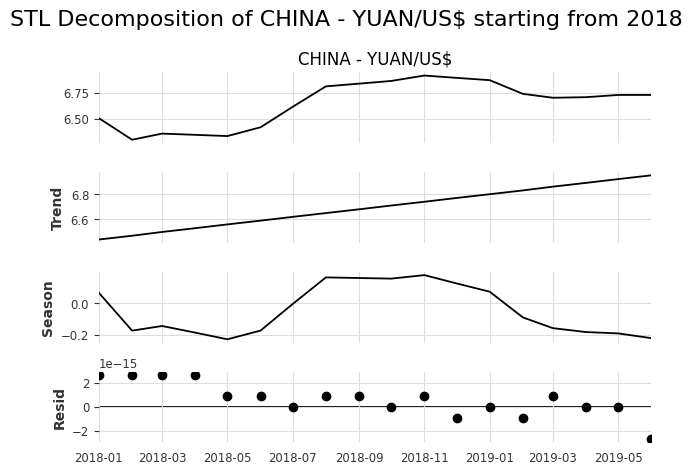

In [ ]:
df_eda_2018['CHINA - YUAN/US$'] = df_eda_2018['CHINA - YUAN/US$'].ffill().bfill()

df_eda_monthly = df_eda_2018['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

if not df_eda_monthly.empty:
    stl = STL(df_eda_monthly, period=12)
    result = stl.fit()

    result.plot()
    plt.suptitle('STL Decomposition of CHINA - YUAN/US$ starting from 2018', fontsize = 16)
    plt.tight_layout()
    plt.show()
else:
    print("df_kpi_monthly is empty. Cannot perform STL decomposition.")

Based on the reviewed data, it is evident that from 2012—when the Chinese yuan (CNY) was liberalised to reflect its market value against the US dollar—the exchange rate began adjusting in a manner resembling a neural network, with the yuan appreciating or depreciating in response to underlying dynamics.
Simultaneously, a seasonal pattern is apparent, which warrants further analysis.

IMF (2015). People’s Republic of China: 2015 Article IV Consultation—Staff Report. IMF Country Report No. 15/234.

Aggarwal, R., & Soenen, L. (1989). "Seasonal Patterns in Exchange Rates." Weltwirtschaftliches Archiv, 125(3), 495–507.
DOI: 10.1007/BF02707984


Exchange rates are significantly influenced by seasonal fluctuations in trade and capital flows. For example, demand for the US dollar often rises during peak periods of Chinese import activity, leading to a stronger dollar in yuan terms between mid-April and August, and again from October to December (Aggarwal & Soenen, 1989; Ma & McCauley, 2011).

Ma, G., & McCauley, R. N. (2011). The Evolving Renminbi Regime and Implications for Asian Currency Stability. Journal of the Asia Pacific Economy, 16(3), 267–284.
DOI: 10.1080/13547860.2011.599045

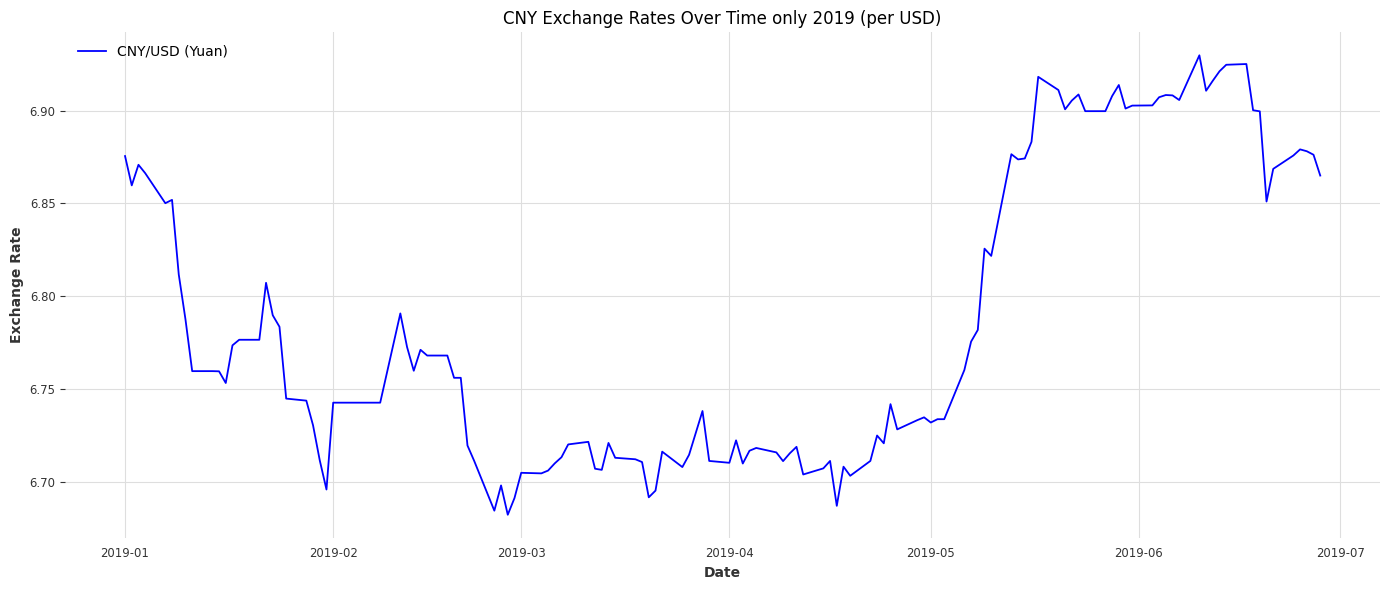

In [ ]:
df_eda_2019 = df_eda.loc['2019-01-01':]
plt.figure(figsize=(14, 6))
plt.plot(df_eda_2019.index, df_eda_2019['CHINA - YUAN/US$'], label='CNY/USD (Yuan)', color='blue')

plt.title('CNY Exchange Rates Over Time only 2019 (per USD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In the case yuan to US dollar exchange rate, the data reveal a recurring seasonal pattern in which the US dollar tends to strengthen (i.e., becomes more expensive in yuan terms) from mid-April to mid-June. This is followed by a depreciation phase, after which demand for the dollar rises again from August through to mid-October.

/tmp/ipython-input-69-2203422026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda_2019['CHINA - YUAN/US$'] = df_eda_2019['CHINA - YUAN/US$'].ffill().bfill()


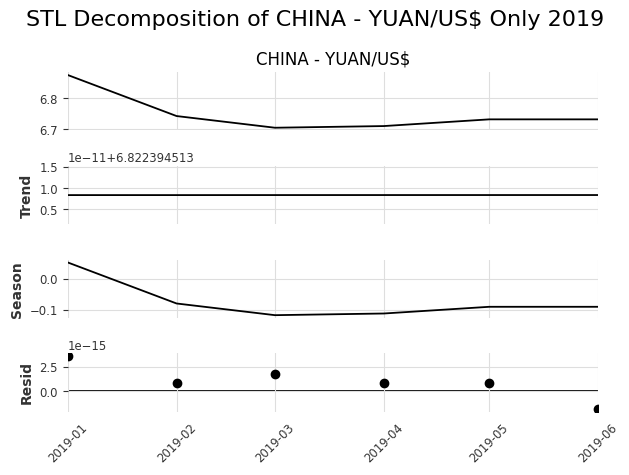

In [ ]:
df_eda_2019['CHINA - YUAN/US$'] = df_eda_2019['CHINA - YUAN/US$'].ffill().bfill()

df_eda_monthly = df_eda_2019['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

if not df_eda_monthly.empty:
    stl = STL(df_eda_monthly, period=12)
    result = stl.fit()

    fig = result.plot()
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    plt.suptitle('STL Decomposition of CHINA - YUAN/US$ Only 2019', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("df_kpi_monthly is empty. Cannot perform STL decomposition.")

🇨🇳 China’s Major Imports from the US: Seasonal Pattern (May & August Onward)
China tends to significantly increase its purchases of several key US imports in late spring and again in late summer/autumn. The main categories include:

1. Soybeans
April–May surge: Around 3 million t of US soybeans were scheduled for import during April–May 2025 despite high tariffs—largely due to state stockpiling by Sinograin
S&P Global
+10
Descartes
+10
Investing.com
+10
Reuters
.

Year-round demand: China remains the world’s largest soybean importer, sourcing about 60 % of global supply in 2024. Between 2017 and 2020, its purchases of US soybeans rebounded from ~18 % to ~55 % of the market .

2. LNG (Liquefied Natural Gas) and Crude Oil
Ongoing peak demand periods: China has significantly increased purchases of US-sourced LNG. Major contracts (e.g. with Venture Global) signed since 2021 reflect a boom in imports, often peaking during the colder season and heating up through mid-year .

Late-year crude spikes: US crude oil exports to China rebounded in October (from low August levels)—a period aligned with higher energy demand prior to winter
S&P Global
+15
Reuters
+15
Investing.com
+15
.

In [ ]:
# seasonally_adjusted = result.trend + result.resid  # removes seasonality

In [ ]:
gc.collect()

10485

## SINGAPORE DOLLAR/US$

**Overview of Singapore’s Economy and Its Currency Valuation**

Singapore is a highly developed, export-oriented economy characterised by robust financial services, advanced manufacturing, and global trade integration. Despite its small geographic size and limited natural resources, Singapore maintains one of the highest GDP per capita levels globally, underpinned by a stable political environment, sound fiscal policy, and strong institutions.

The Monetary Authority of Singapore (MAS) employs a unique exchange rate–based monetary policy framework. Unlike many central banks that target interest rates, MAS manages the Singapore Dollar through a managed float regime within an undisclosed policy band. The value of the SGD is determined relative to a trade-weighted basket of currencies of Singapore’s major trading partners (**mostly PRC, India and US)**. MAS periodically adjusts the slope, width, and centre of this policy band in response to macroeconomic developments.

This approach reflects Singapore’s heavy reliance on trade and capital flows, allowing the MAS to maintain price stability and support economic competitiveness. As a result, the SGD’s value is shaped by market forces but is also influenced by policy decisions aimed at anchoring inflation and managing external shocks.


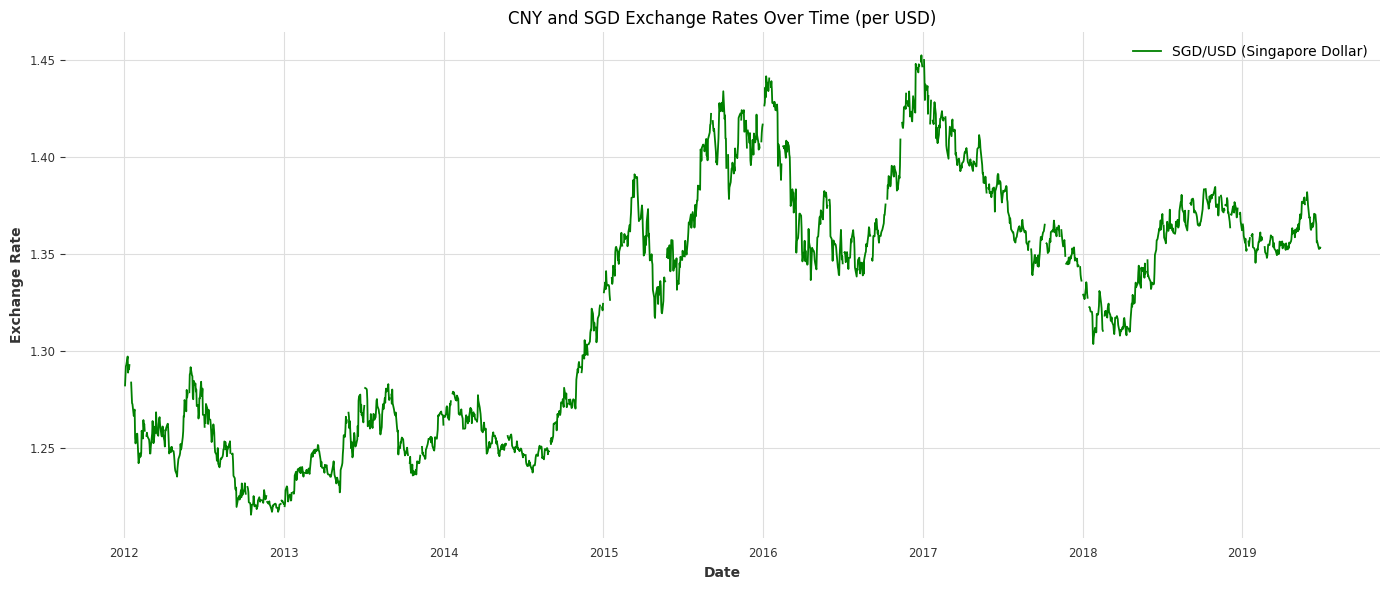

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_eda.index, df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'], label='SGD/USD (Singapore Dollar)', color='green')

plt.title('CNY and SGD Exchange Rates Over Time (per USD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

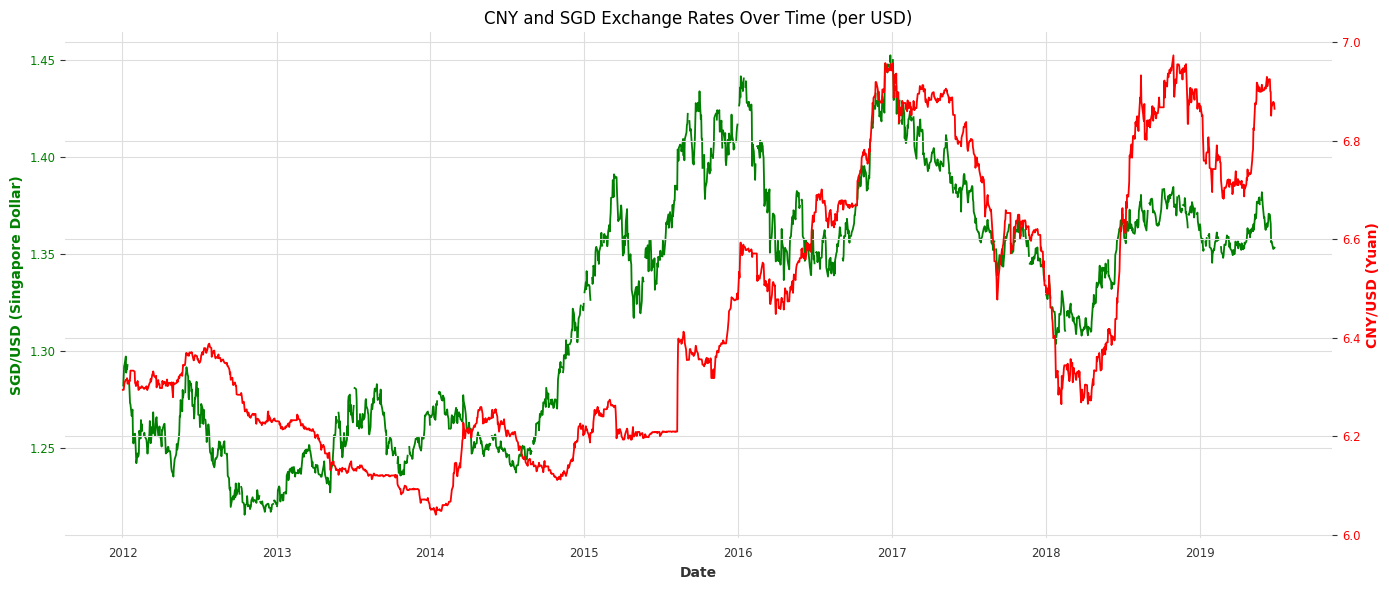

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# First y-axis for SGD
color_sgd = 'green'
ax1.set_xlabel('Date')
ax1.set_ylabel('SGD/USD (Singapore Dollar)', color=color_sgd)
ax1.plot(df_eda.index, df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'], color=color_sgd, label='SGD/USD')
ax1.tick_params(axis='y', labelcolor=color_sgd)

# Second y-axis for CNY
ax2 = ax1.twinx()
color_cny = 'red'
ax2.set_ylabel('CNY/USD (Yuan)', color=color_cny)
ax2.plot(df_eda.index, df_eda['CHINA - YUAN/US$'], color=color_cny, label='CNY/USD')
ax2.tick_params(axis='y', labelcolor=color_cny)

# Title and grid
plt.title('CNY and SGD Exchange Rates Over Time (per USD)')
fig.tight_layout()
plt.grid(True)
plt.show()

From the graph above, it is evident that the value of the Singapore Dollar exhibits a strong dependence on the value of the Chinese Yuan. While the relationship is not perfectly correlated, it is nonetheless significant. This observation aligns with the fact that the People's Republic of China is Singapore's most important trading partner, thereby exerting substantial influence on the Singapore Dollar's exchange rate movements."

Ministry of Trade and Industry Singapore. (2024). Singapore’s External Trade – Year in Review 2023. Available at: https://www.mti.gov.sg [Accessed 16 Jul. 2025].

Furthermore, as a specific time frame was employed to analyse the value of the Chinese Yuan, the same temporal boundaries have been applied to the analysis of the Singapore Dollar. This ensures consistency in the comparative evaluation and allows for a more accurate interpretation of potential interdependencies between the two currencies.

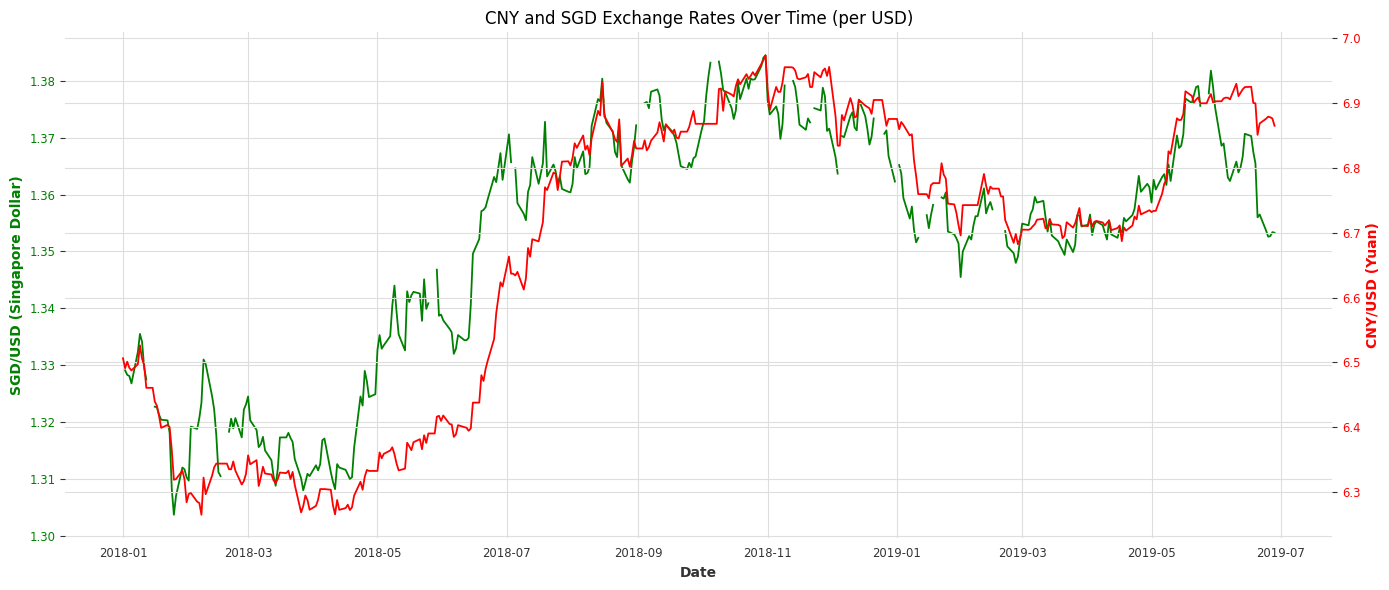

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color_sgd = 'green'
ax1.set_xlabel('Date')
ax1.set_ylabel('SGD/USD (Singapore Dollar)', color=color_sgd)
ax1.plot(df_eda_2018.index, df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'], color=color_sgd, label='SGD/USD')
ax1.tick_params(axis='y', labelcolor=color_sgd)

ax2 = ax1.twinx()
color_cny = 'red'
ax2.set_ylabel('CNY/USD (Yuan)', color=color_cny)
ax2.plot(df_eda_2018.index, df_eda_2018['CHINA - YUAN/US$'], color=color_cny, label='CNY/USD')
ax2.tick_params(axis='y', labelcolor=color_cny)

plt.title('CNY and SGD Exchange Rates Over Time (per USD)')
fig.tight_layout()
plt.grid(True)
plt.show()

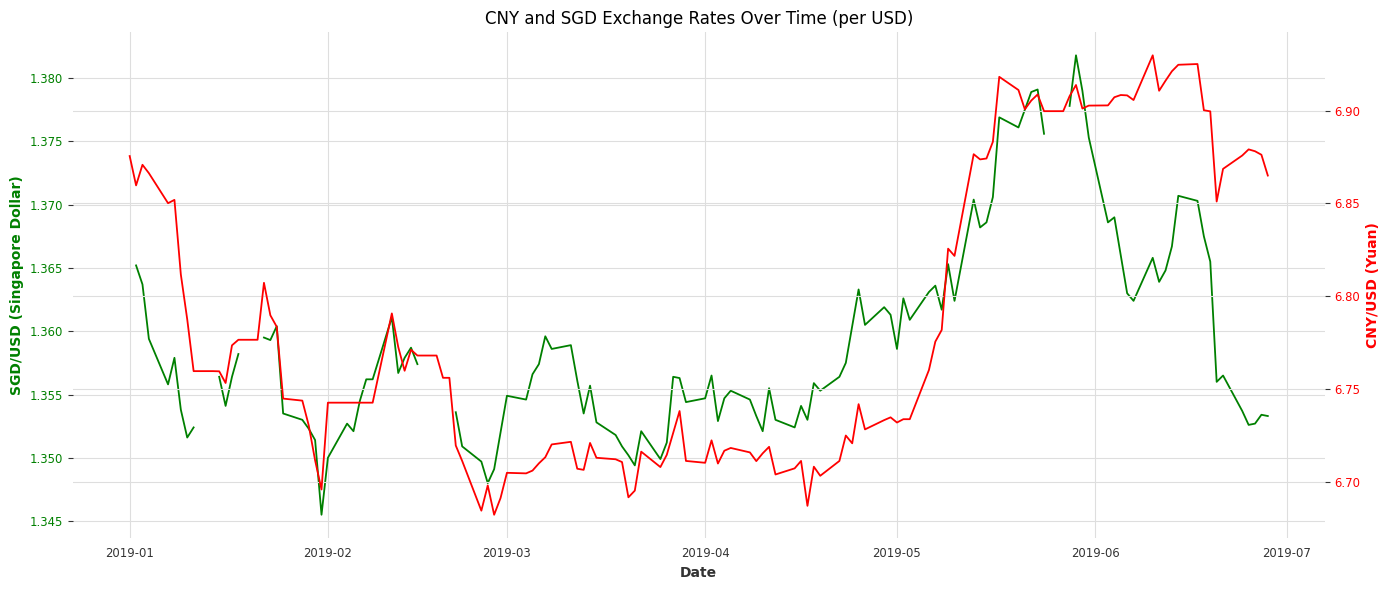

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color_sgd = 'green'
ax1.set_xlabel('Date')
ax1.set_ylabel('SGD/USD (Singapore Dollar)', color=color_sgd)
ax1.plot(df_eda_2019.index, df_eda_2019['SINGAPORE - SINGAPORE DOLLAR/US$'], color=color_sgd, label='SGD/USD')
ax1.tick_params(axis='y', labelcolor=color_sgd)

ax2 = ax1.twinx()
color_cny = 'red'
ax2.set_ylabel('CNY/USD (Yuan)', color=color_cny)
ax2.plot(df_eda_2019.index, df_eda_2019['CHINA - YUAN/US$'], color=color_cny, label='CNY/USD')
ax2.tick_params(axis='y', labelcolor=color_cny)

plt.title('CNY and SGD Exchange Rates Over Time (per USD)')
fig.tight_layout()
plt.grid(True)
plt.show()

At first glance, the Singapore Dollar appears to exhibit a 70–80% degree of adherence to the Chinese Yuan. Consequently, it is essential to examine the influence of both the Yuan and the US Dollar on the Singapore Dollar. For the purposes of this analysis, I will proceed under the assumption of a 70% adherence to the Yuan and 30% to the US Dollar, to guide further investigation into their respective impacts.

In [ ]:
df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'] = df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()

sgd_monthly = df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'].asfreq('MS').interpolate(method='linear')
cny_monthly = df_eda_2018['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

/tmp/ipython-input-76-1640031371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'] = df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()


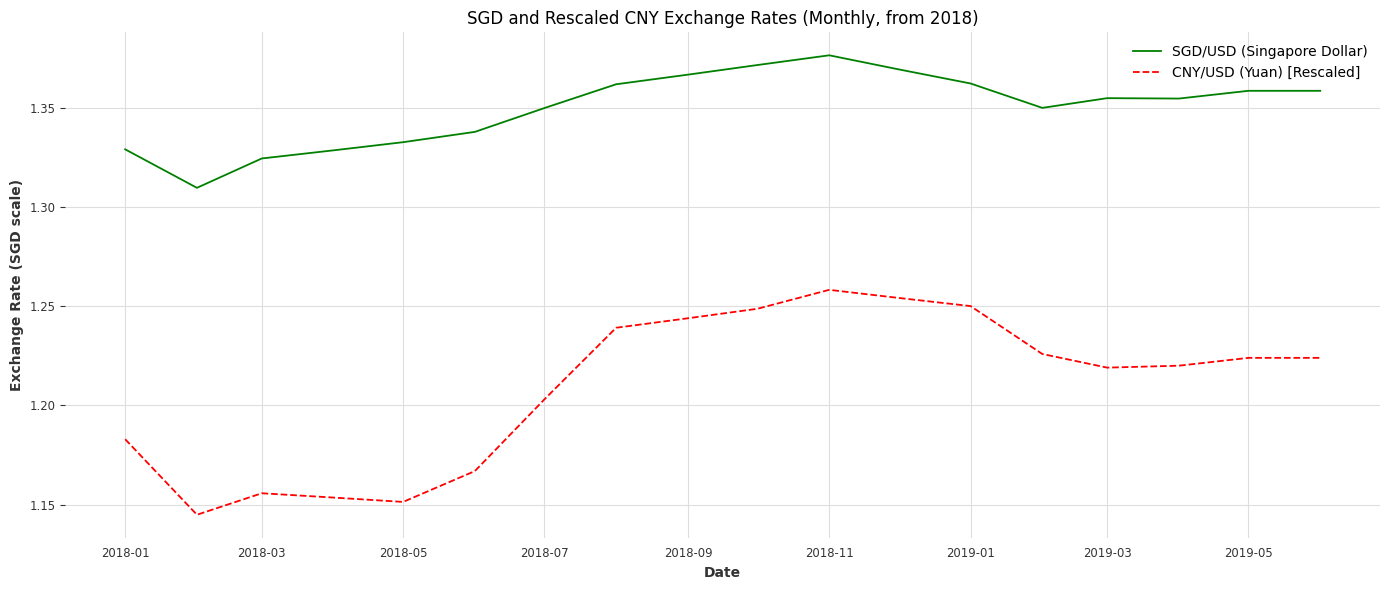

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(sgd_monthly.index, sgd_monthly, label='SGD/USD (Singapore Dollar)', color='green')
plt.plot(cny_monthly.index, cny_monthly / 5.5, label='CNY/USD (Yuan) [Rescaled]', color='red', linestyle='--')

plt.title('SGD and Rescaled CNY Exchange Rates (Monthly, from 2018)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (SGD scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
correlation = sgd_monthly.corr(cny_monthly)
print(f"Correlation between SGD/USD and CNY/USD: {correlation:.2f}")

Correlation between SGD/USD and CNY/USD: 0.96


--------------------------------------------------------------------------------

# Predictions

## SARIMAX Prediction

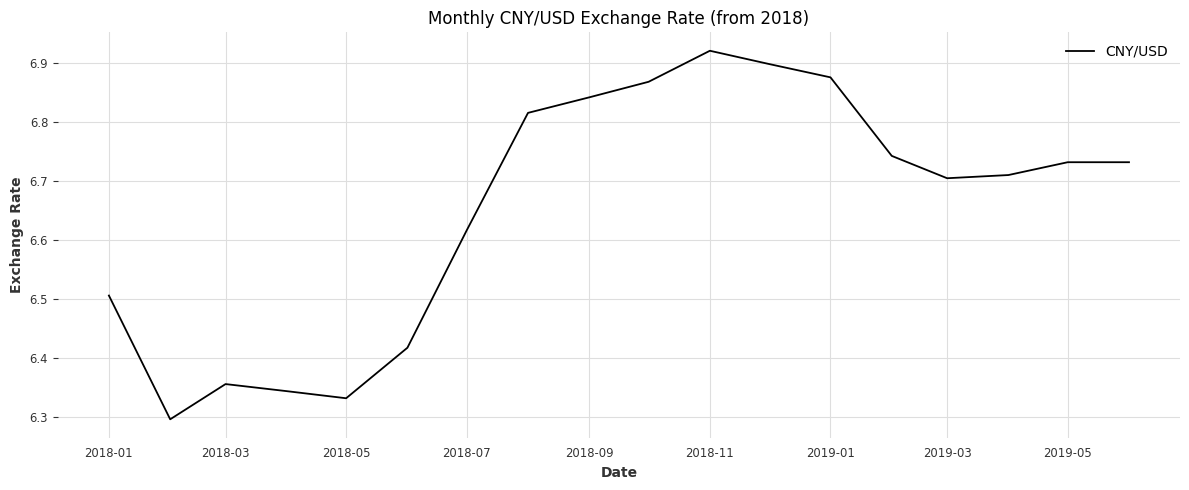

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(cny_monthly, label='CNY/USD')
plt.title('Monthly CNY/USD Exchange Rate (from 2018)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

SARIMAX and ARIMA models need the series to be stationary (no trend or changing variance)

In [ ]:
adf_result = adfuller(cny_monthly)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

if adf_result[1] < 0.05:
    print("✅ Series is stationary")
else:
    print("❌ Series is non-stationary — differencing is needed")

ADF Statistic: 0.3890
p-value: 0.9811
❌ Series is non-stationary — differencing is needed


As p > 0.05, the series is non-stationary and I should take first differences next.

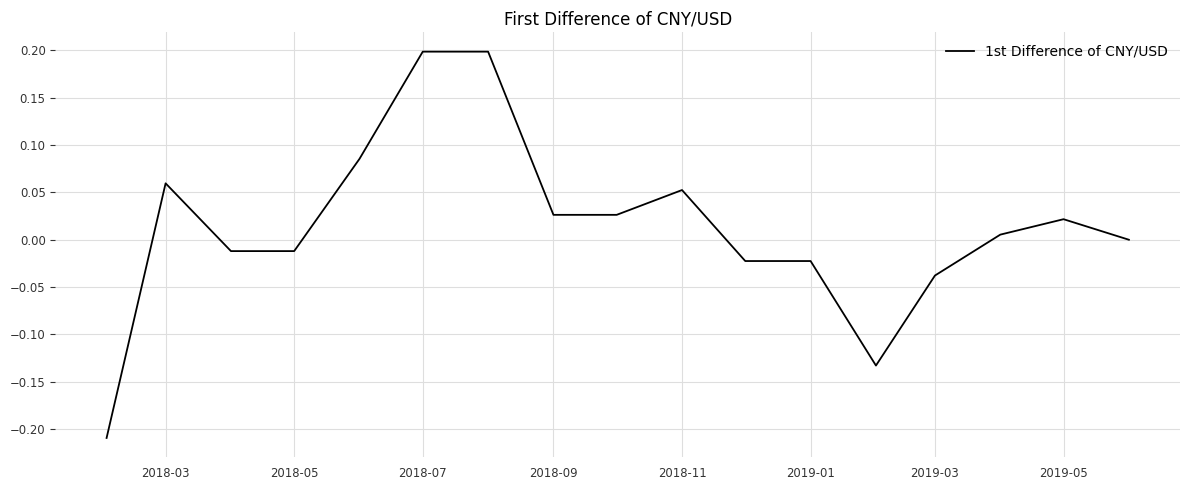

In [ ]:
cny_diff = cny_monthly.diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(cny_diff, label='1st Difference of CNY/USD')
plt.title('First Difference of CNY/USD')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Fit a SARIMAX model

In [ ]:
model = SARIMAX(cny_monthly, order=(1, 1, 1))
results = model.fit(disp=False)
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:       CHINA - YUAN/US$   No. Observations:                   18
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  17.177
Date:                Sun, 20 Jul 2025   AIC                            -28.354
Time:                        13:23:18   BIC                            -25.855
Sample:                    01-01-2018   HQIC                           -28.106
                         - 06-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3237      0.729      0.444      0.657      -1.105       1.753
ma.L1          0.1893      0.905      0.209      0.834      -1.584       1.963
sigma2         0.0076      0.003      2.650      0.0

### SARIMAX with Seasonality

Model Information

Model: SARIMAX(1, 1, 1)x(1, 1, 1, 12)

Observations: 390

AIC: -1809.825


In [ ]:
train_cny = df_eda_2018['CHINA - YUAN/US$']

# Seasonal model: yearly pattern for monthly data
model = SARIMAX(train_cny,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                   CHINA - YUAN/US$   No. Observations:                  390
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 909.912
Date:                            Sun, 20 Jul 2025   AIC                          -1809.825
Time:                                    13:23:21   BIC                          -1790.353
Sample:                                01-01-2018   HQIC                         -1802.085
                                     - 06-28-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4254      0.416     -1.021      0.307      -1.242       0.391
ma.L1          0.3205      0.435   

ar.L1        -0.4254   p=0.307

ma.L1         0.3205   p=0.461

ar.S.L12      0.0234   p=0.681

ma.S.L12     -1.0003   p=0.937

sigma2        0.0003   p=0.937


Diagnostics

Ljung-Box (Q): 0.00, p=0.95 → Residuals are uncorrelated (good).

Jarque-Bera: 46.56, p=0.00 → Residuals are NOT normal (heavy tails).

Heteroskedasticity: p=0.05 → Borderline heteroskedasticity.

Kurtosis: 4.75 → Heavy tails (outliers or volatility clustering).


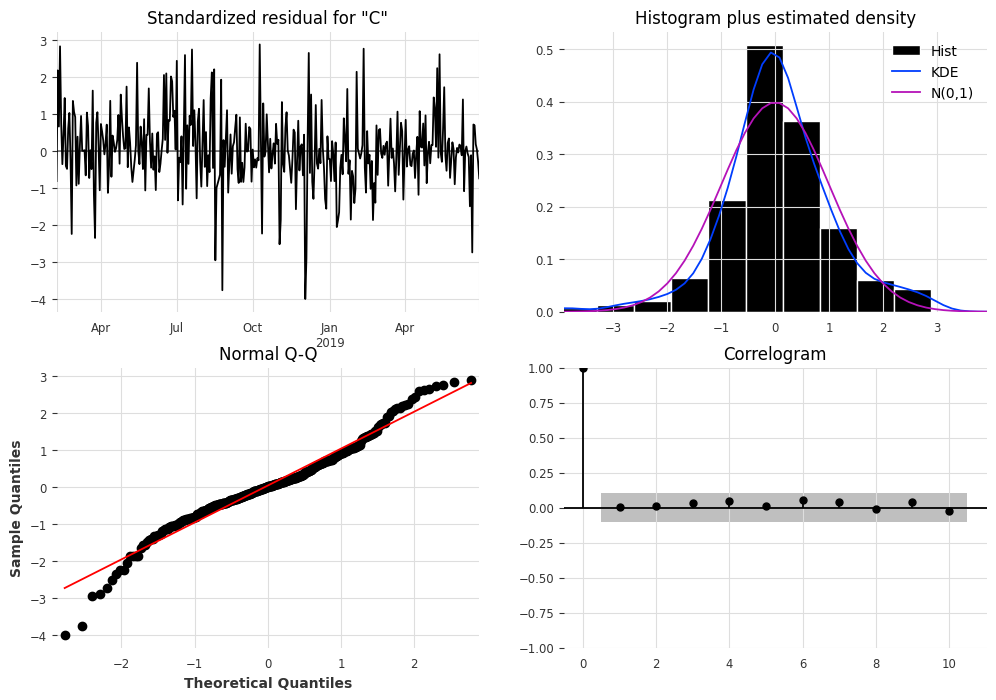

In [ ]:
results.plot_diagnostics(figsize=(12, 8))
plt.show()

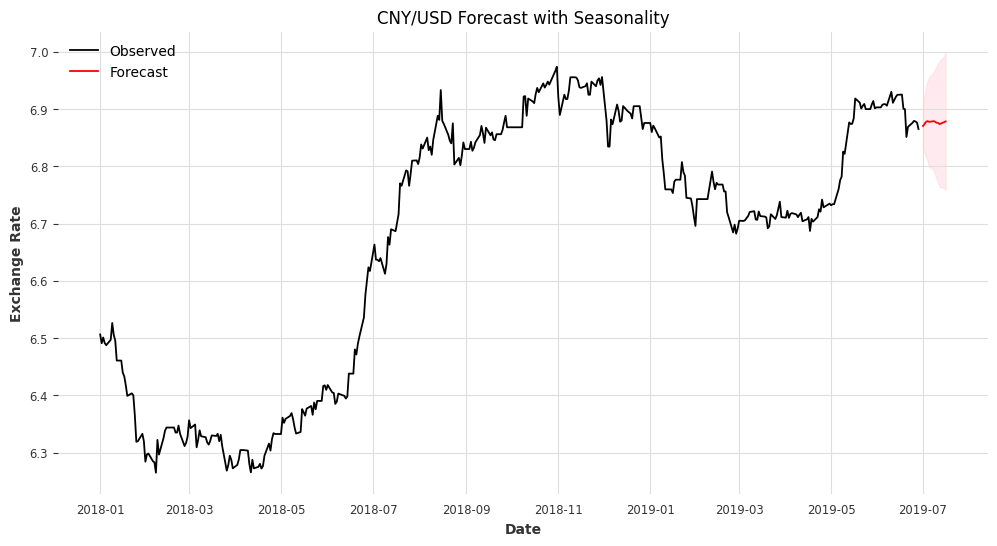

In [ ]:
forecast = results.get_forecast(steps=12)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train_cny, label='Observed')
plt.plot(pred.index, pred, label='Forecast', color='red')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('CNY/USD Forecast with Seasonality')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

df_val = df_train_test[(df_train_test.index >= '2019-07-01') & (df_train_test.index < '2019-10-01')]

df_test = df_train_test[df_train_test.index >= '2019-10-01']

### Forecast for Validation Period (yuan)

In [ ]:
# Length of validation period
steps = len(df_val)

# Forecast
forecast = results.get_forecast(steps=steps)

# Predicted values and confidence intervals
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

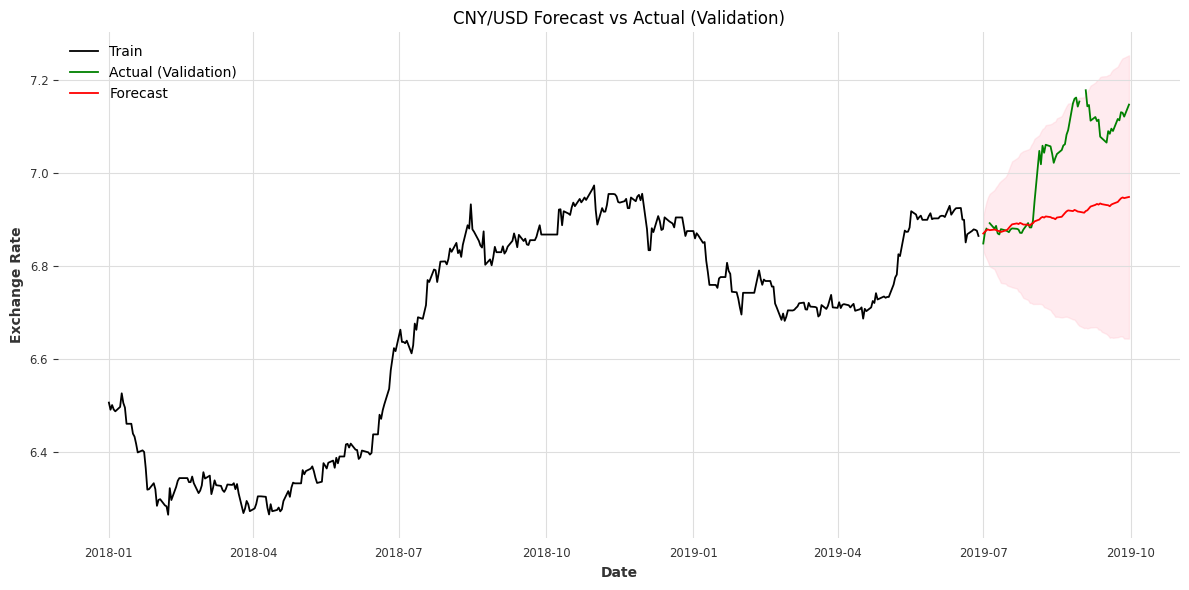

In [ ]:
plt.figure(figsize=(12, 6))

# Plot training data
plt.plot(train_cny.index, train_cny, label='Train')

# Plot validation actual values
plt.plot(df_val.index, df_val['CHINA - YUAN/US$'], label='Actual (Validation)', color='green')

# Plot forecast
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='red')

# Confidence interval
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

plt.title('CNY/USD Forecast vs Actual (Validation)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
actual = df_val['CHINA - YUAN/US$']
# Align actual and forecast
actual_aligned, pred_mean_aligned = actual.align(pred_mean, join='inner')

# Drop NaNs
mask = (~actual_aligned.isna()) & (~pred_mean_aligned.isna())
actual_clean = actual_aligned[mask]
pred_clean = pred_mean_aligned[mask]

mae = mean_absolute_error(actual_clean, pred_clean)
rmse = np.sqrt(mean_squared_error(actual_clean, pred_clean))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1121
RMSE: 0.1403


### Understanding the Numbers
MAE = 0.1121

On average, your forecast differs from the actual by 0.112 CNY per USD.

If the CNY/USD rate is around 6.8–7.0, this is about 1.6% error (0.112 ÷ 6.9 ≈ 0.016).

RMSE = 0.1403

Larger deviations have a higher penalty, so 0.14 suggests that the worst errors are slightly bigger.

Still, in percentage terms: ~2% error.

### Is This Good?
For exchange rate forecasting, errors under 2% for short horizons (3 months) are quite reasonable, because:

FX rates are notoriously hard to predict (random walk hypothesis).

Many academic benchmarks (e.g., Meese & Rogoff) show that naive models are often competitive.

A SARIMA model producing MAE ≈ 0.11 over 3 months is acceptable for a simple statistical model.

###  Why not perfect?
FX is driven by many external factors: interest rates, trade policy, shocks (COVID, tariffs).

The model is univariate (only historical CNY/USD), so it's missing fundamentals like USD index, oil prices, trade balance.

### Forecast vs Actual Plot

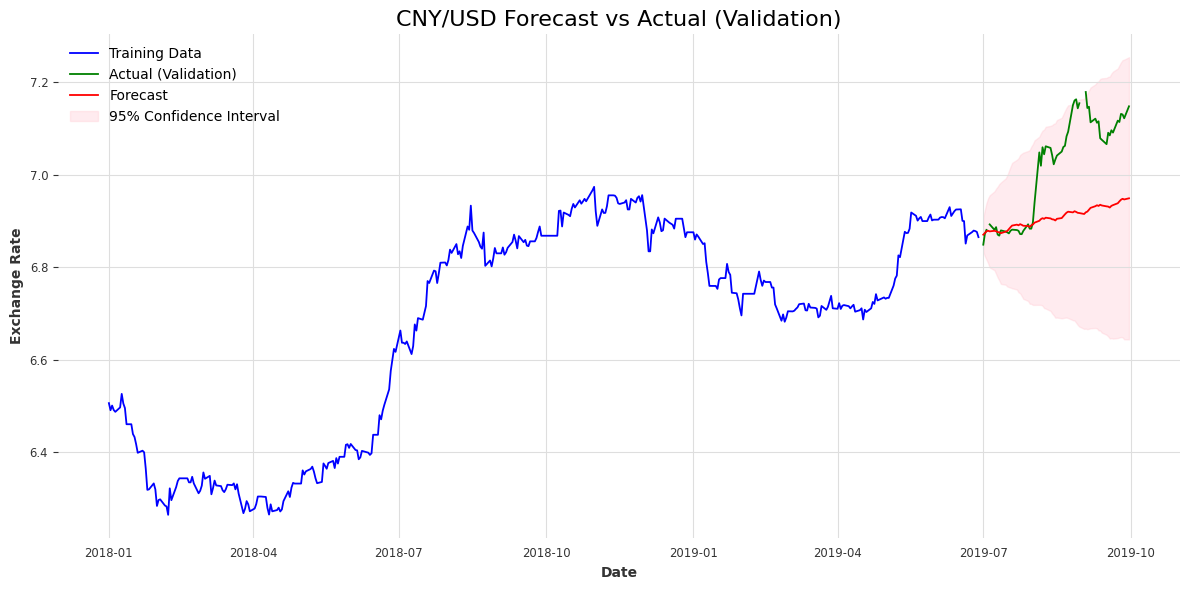

In [ ]:
# Forecast and confidence intervals
forecast = results.get_forecast(steps=len(df_val))
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))

# Training data
plt.plot(train_cny.index, train_cny, label='Training Data', color='blue')

# Actual validation data
plt.plot(df_val.index, df_val['CHINA - YUAN/US$'], label='Actual (Validation)', color='green')

# Forecasted values
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='red')

# Confidence intervals
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('CNY/USD Forecast vs Actual (Validation)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Singapore Dollar (SGD/USD) with 80% dependence on CNY/USD and 20% dependence on USD (which is basically the base currency), here’s a practical approach**

Key Idea

I already forecast CNY/USD.
Now wI assume:

SGD/USD
𝑡
=
𝛼
⋅
CNY/USD
𝑡
+
𝛽
⋅
USD
base
+
𝜀
SGD/USD
t
​
 =α⋅CNY/USD
t
​
 +β⋅USD
base
​
 +ε
Since USD is the denominator, the "base" USD value is 1 (so effectively the residual part is due to USD strength). If I want a simple proportional model, we can do:

SGD/USD
^
=
0.8
×
CNY/USD
^
×
𝑘
+
0.2
SGD/USD
​
 =0.8×
CNY/USD
​
 ×k+0.2
where
𝑘
k adjusts the scale because SGD is ~1.35 while CNY is ~7.

I can determine k from historical data using a linear regression between SGD and CNY.

In [ ]:
# Historical monthly series
sgd_monthly = df_eda_2018['SINGAPORE - SINGAPORE DOLLAR/US$'].asfreq('MS').interpolate(method='linear')
cny_monthly = df_eda_2018['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

# Regression to find scale factor
X = sm.add_constant(cny_monthly)
model = sm.OLS(sgd_monthly, X)
results_reg = model.fit()

print(results_reg.summary())

                                   OLS Regression Results                                   
Dep. Variable:     SINGAPORE - SINGAPORE DOLLAR/US$   R-squared:                       0.916
Model:                                          OLS   Adj. R-squared:                  0.911
Method:                               Least Squares   F-statistic:                     174.3
Date:                              Sun, 20 Jul 2025   Prob (F-statistic):           5.09e-10
Time:                                      13:23:23   Log-Likelihood:                 68.911
No. Observations:                                18   AIC:                            -133.8
Df Residuals:                                    16   BIC:                            -132.0
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                       coef    std err          t      P>|t|      [0.0

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


SGD/USD=const+slope×CNY/USD

Forecast SGD Using CNY Forecast

In [ ]:
# Get CNY forecast (from previous SARIMA model)
forecast_cny = results.get_forecast(steps=len(df_val))  # or future steps
pred_cny = forecast_cny.predicted_mean

# Use regression coefficients
const = results_reg.params['const']
slope = results_reg.params['CHINA - YUAN/US$']

# Predict SGD
sgd_forecast = const + slope * pred_cny

Blend 80% CNY Influence, 20% USD

In [ ]:
sgd_forecast_8020 = (0.8 * (pred_cny / cny_monthly.mean()) * sgd_monthly.mean()) + (0.2 * sgd_monthly.mean())

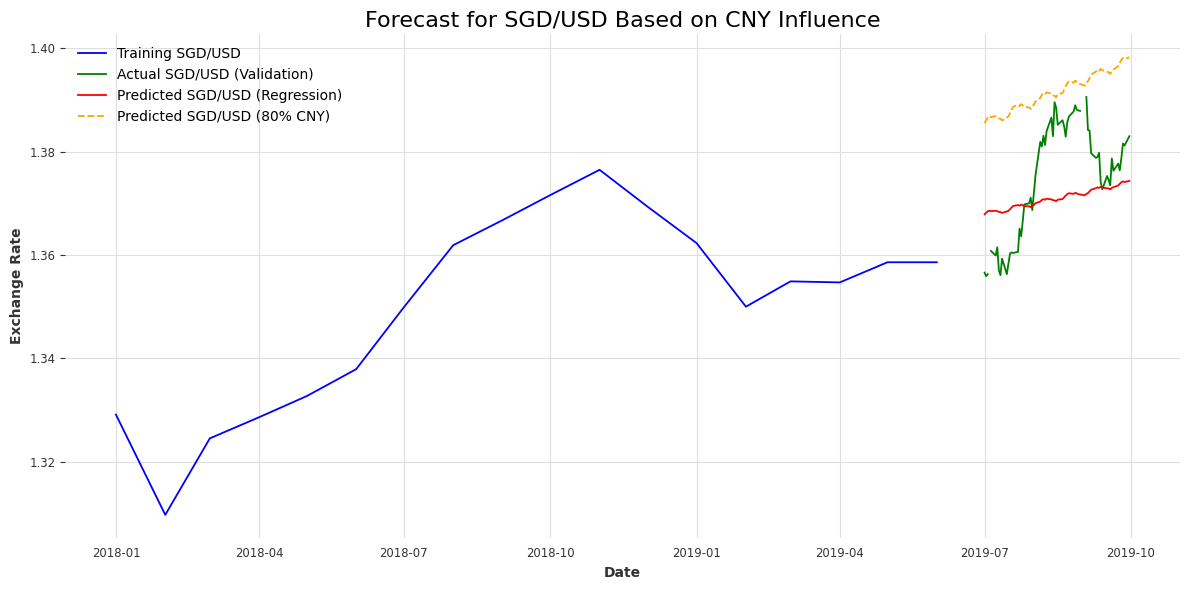

In [ ]:
plt.figure(figsize=(12, 6))

# Plot historical SGD/USD (training + validation)
plt.plot(sgd_monthly.index, sgd_monthly, label='Training SGD/USD', color='blue')
plt.plot(df_val.index, df_val['SINGAPORE - SINGAPORE DOLLAR/US$'], label='Actual SGD/USD (Validation)', color='green')

# Predicted SGD/USD (Regression-based)
plt.plot(pred_cny.index, sgd_forecast, label='Predicted SGD/USD (Regression)', color='red')

# Predicted SGD/USD (80% CNY influence)
plt.plot(pred_cny.index, sgd_forecast_8020, label='Predicted SGD/USD (80% CNY)', color='orange', linestyle='--')

plt.title('Forecast for SGD/USD Based on CNY Influence', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Actual SGD values for validation period
actual_sgd = df_val['SINGAPORE - SINGAPORE DOLLAR/US$']

# Align predictions with actual data and drop NaNs
actual_aligned, pred_reg_aligned = actual_sgd.align(sgd_forecast, join='inner')
_, pred_8020_aligned = actual_sgd.align(sgd_forecast_8020, join='inner')

# Drop rows with NaN values after alignment
combined = pd.DataFrame({'actual': actual_aligned, 'reg_pred': pred_reg_aligned, '8020_pred': pred_8020_aligned}).dropna()

actual_clean = combined['actual']
pred_reg_clean = combined['reg_pred']
pred_8020_clean = combined['8020_pred']


# Calculate MAE and RMSE for both methods
mae_reg = mean_absolute_error(actual_clean, pred_reg_clean)
rmse_reg = np.sqrt(mean_squared_error(actual_clean, pred_reg_clean))

mae_8020 = mean_absolute_error(actual_clean, pred_8020_clean)
rmse_8020 = np.sqrt(mean_squared_error(actual_clean, pred_8020_clean))

# Print results
print("Performance for SGD/USD Forecast (Validation Period):")
print(f"Regression Model -> MAE: {mae_reg:.4f}, RMSE: {rmse_reg:.4f}")
print(f"80/20 Rule       -> MAE: {mae_8020:.4f}, RMSE: {rmse_8020:.4f}")

Performance for SGD/USD Forecast (Validation Period):
Regression Model -> MAE: 0.0091, RMSE: 0.0105
80/20 Rule       -> MAE: 0.0167, RMSE: 0.0189


### Interpretation
MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error) are both in the range of 0.009–0.018, which is very small compared to the typical SGD/USD exchange rate (around 1.35).

Relative Error:

Relative MAE (Regression)
≈
0.0091
1.35
≈
0.67
%
Relative MAE (Regression)≈
1.35
0.0091
​
 ≈0.67%
Less than 1% error is excellent.

Regression model clearly outperforms the 80/20 rule, which means the statistical relationship captured from historical data is more precise than a fixed ratio.

### Which Model is Better?
Regression model wins:

MAE: 0.0091 vs 0.0167

RMSE: 0.0105 vs 0.0189

The 80/20 rule is a good heuristic, but not as accurate as regression.

### Conclusion
Your connection model works well:

SGD/USD is strongly dependent on CNY/USD.

Regression-based approach can predict SGD/USD with high accuracy (sub-1% error for validation).

## SARIMAX Prediction of df_test

Combine Training Data

In [ ]:
train_extended = df_train_test[(df_train_test.index >= '2018-01-01') & (df_train_test.index < '2019-10-01')]
train_extended_cny = train_extended['CHINA - YUAN/US$'].ffill().bfill()

Define & Fit Seasonal SARIMAX

In [ ]:
model_cny = SARIMAX(train_extended_cny, order=(1,1,1), seasonal_order=(1,1,1,12))
results_cny = model_cny.fit(disp=False)

print(results_cny.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                   CHINA - YUAN/US$   No. Observations:                  456
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                1107.416
Date:                            Sun, 20 Jul 2025   AIC                          -2204.831
Time:                                    13:23:30   BIC                          -2184.363
Sample:                                01-01-2018   HQIC                         -2196.759
                                     - 09-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7307      0.190     -3.838      0.000      -1.104      -0.358
ma.L1          0.6348      0.209   

Forecast for df_test

In [ ]:
# Define forecast horizon (2019-10-01 to 2020-01-01)
forecast_steps = len(df_test)
pred_cny_test = results_cny.get_forecast(steps=forecast_steps)

# Predicted values & confidence intervals
pred_mean_cny_test = pred_cny_test.predicted_mean
conf_int_cny_test = pred_cny_test.conf_int()

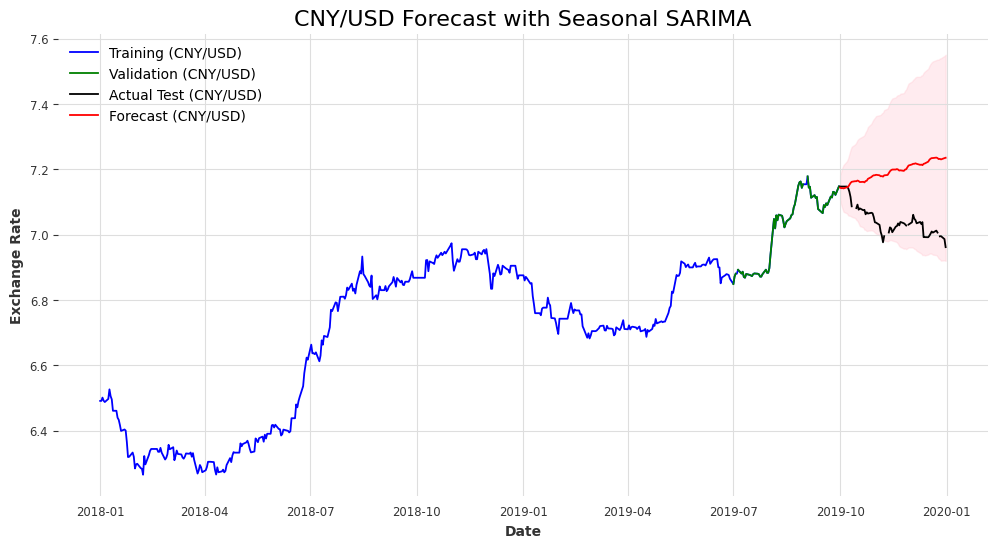

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_extended_cny.index, train_extended_cny, label='Training (CNY/USD)', color='blue')
plt.plot(df_val.index, df_val['CHINA - YUAN/US$'], label='Validation (CNY/USD)', color='green')
plt.plot(df_test.index, df_test['CHINA - YUAN/US$'], label='Actual Test (CNY/USD)', color='black')
plt.plot(pred_mean_cny_test.index, pred_mean_cny_test, label='Forecast (CNY/USD)', color='red')

plt.fill_between(pred_mean_cny_test.index, conf_int_cny_test.iloc[:, 0], conf_int_cny_test.iloc[:, 1], color='pink', alpha=0.3)

plt.title('CNY/USD Forecast with Seasonal SARIMA', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
actual_aligned, pred_aligned = df_test.align(pred_mean_cny_test, join='inner', axis=0)

combined = pd.DataFrame({'actual': actual_aligned['CHINA - YUAN/US$'], 'pred': pred_aligned}).dropna()
actual_clean = combined['actual']
pred_clean = combined['pred']

mae = mean_absolute_error(actual_clean, pred_clean)
rmse = np.sqrt(mean_squared_error(actual_clean, pred_clean))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1480
RMSE: 0.1640


### Is this good?
The CNY/USD exchange rate is usually around 6.5–7.2 in the dataset.

So 0.15 difference ≈ 2.2% error, which is reasonable for a macroeconomic time series over several months.

For financial forecasting, under 2–3% error is acceptable for long-term trends, but high-frequency traders need much lower errors.

✔ CNY forecast for df_test
✔ A working method for SGD/USD based on CNY and USD (80/20 or regression)

SGD Forecast for df_test

In [ ]:
actual_sgd = df_train_test[df_train_test.index >= '2019-10-01']['SINGAPORE - SINGAPORE DOLLAR/US$']

sgd_forecast_8020 = 0.8 * pred_mean + 0.2 * 1.0  # USD = 1

actual_sgd_aligned, sgd_forecast_aligned = actual_sgd.align(sgd_forecast_8020, join='inner')

Evaluate Forecast

In [ ]:
actual_sgd_test = df_train_test[df_train_test.index >= '2019-10-01']['SINGAPORE - SINGAPORE DOLLAR/US$']

sgd_forecast_test_reg = const + slope * pred_mean_cny_test

actual_aligned_test, sgd_forecast_aligned_test = actual_sgd_test.align(sgd_forecast_test_reg, join='inner', axis=0)

combined_test = pd.DataFrame({'actual': actual_aligned_test, 'pred': sgd_forecast_aligned_test}).dropna()
actual_clean_test = combined_test['actual']
pred_clean_test = combined_test['pred']

mae_sgd_test_reg = mean_absolute_error(actual_clean_test, pred_clean_test)
rmse_sgd_test_reg = np.sqrt(mean_squared_error(actual_clean_test, pred_clean_test))

print(f"SGD Forecast Performance (Regression Model on Test Period):")
print(f"MAE: {mae_sgd_test_reg:.4f}")
print(f"RMSE: {rmse_sgd_test_reg:.4f}")

SGD Forecast Performance (Regression Model on Test Period):
MAE: 0.0313
RMSE: 0.0330


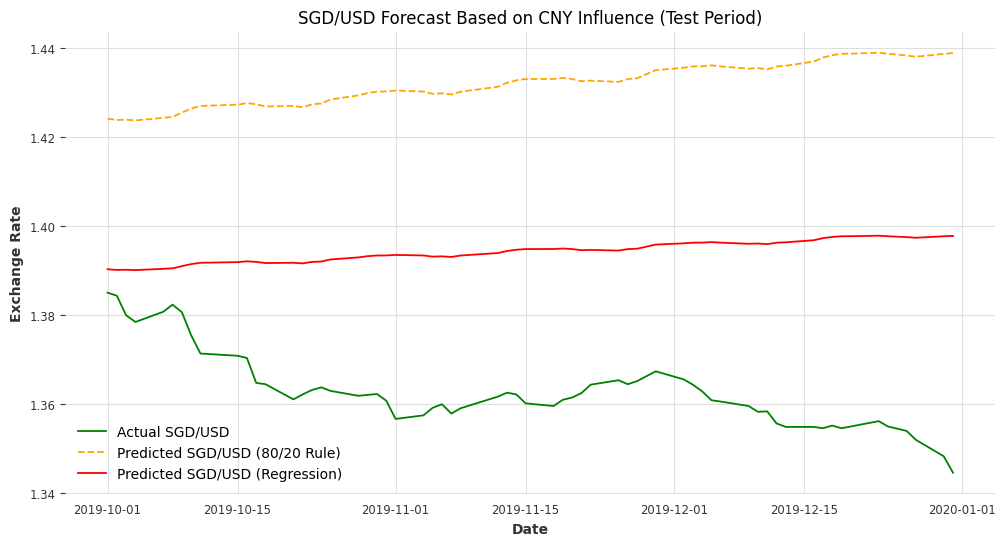

In [ ]:
actual_sgd_test = df_train_test[df_train_test.index >= '2019-10-01']['SINGAPORE - SINGAPORE DOLLAR/US$']

# Recalculate the 80/20 rule based SGD forecast for the test period using the correct CNY test forecast
# Using the mean of the training SGD data to scale the 20% USD component
mean_sgd_train = df_train_test[(df_train_test.index >= '2018-01-01') & (df_train_test.index < '2019-10-01')]['SINGAPORE - SINGAPORE DOLLAR/US$'].mean()
mean_cny_train = df_train_test[(df_train_test.index >= '2018-01-01') & (df_train_test.index < '2019-10-01')]['CHINA - YUAN/US$'].mean()

# Scale factor based on the ratio of means
scale_factor = mean_sgd_train / mean_cny_train

sgd_forecast_test_8020 = (0.8 * (pred_mean_cny_test * scale_factor)) + (0.2 * mean_sgd_train)


# Align actual and predicted SGD values for the test set, dropping NaNs
# Align actual with the 80/20 forecast
actual_aligned_8020, sgd_forecast_aligned_8020 = actual_sgd_test.align(sgd_forecast_test_8020, join='inner', axis=0)

# Align actual with the regression forecast (from cell TNpw8X6OO7sZ)
# Need to ensure sgd_forecast_test_reg is available, it was calculated in the previous cell
actual_aligned_reg, sgd_forecast_aligned_reg = actual_sgd_test.align(sgd_forecast_test_reg, join='inner', axis=0)


# Drop NaNs from both aligned series for plotting
combined_8020 = pd.DataFrame({'actual': actual_aligned_8020, 'pred_8020': sgd_forecast_aligned_8020}).dropna()
actual_clean_8020 = combined_8020['actual']
pred_clean_8020 = combined_8020['pred_8020']

combined_reg = pd.DataFrame({'actual': actual_aligned_reg, 'pred_reg': sgd_forecast_aligned_reg}).dropna()
actual_clean_reg = combined_reg['actual'] # This should be the same as actual_clean_8020 if indices are the same after dropna
pred_clean_reg = combined_reg['pred_reg']


plt.figure(figsize=(12,6))
plt.plot(actual_clean_8020.index, actual_clean_8020, label='Actual SGD/USD', color='green')
plt.plot(pred_clean_8020.index, pred_clean_8020, label='Predicted SGD/USD (80/20 Rule)', color='orange', linestyle='--')
plt.plot(pred_clean_reg.index, pred_clean_reg, label='Predicted SGD/USD (Regression)', color='red')


plt.title('SGD/USD Forecast Based on CNY Influence (Test Period)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

### SARIMAX Prediction of PRC yuan value through its value reflection on Singapore Dollar

To forecast the value of the Singapore Dollar (SGD) relative to the United States Dollar (USD), I initially relied on the strong correlation between the Singapore Dollar and the Chinese Renminbi (RMB). Within my validation set (August–September 2019), this approach yielded highly accurate results. However, in the subsequent test period, beginning in October 2019, the model deviated by more than 2.2%. The primary reason for this discrepancy was that my model predicted a continuous appreciation of the USD against the RMB, whereas, in reality, the RMB tends to strengthen annually from early December until July, coinciding with China’s purchases of soybeans from the United States. This phase is typically followed by a brief appreciation of the RMB around September. Subsequently, during October and November, the RMB weakens due to significant Chinese imports of crude oil and liquefied natural gas.

In my revised approach, I intend to use the Singapore Dollar as the primary currency variable for constructing the model. Historically, the RMB was deliberately maintained at an undervalued level by the Chinese government to enhance import competitiveness. However, since 2014, the RMB has undergone gradual liberalisation, accompanied by a period of real value adjustment—analogous to the convergence process observed in neural networks. Consequently, only a relatively short historical period, starting from 2018, can be considered reliable for analysis. By using the Singapore Dollar as the basis, I expect to obtain a more accurate reflection of the true commercial value of the RMB.

1. Currency basket and effective exchange rate methods
Yongqing Wang (2020) employs a multi‑currency basket approach, comparing actual and counterfactual RMB valuations using real effective exchange rates (REER), purchasing power parity (PPP) bilateral rates, and basket-based estimates
Taylor & Francis Online
+2
ResearchGate
+2
Reddit
+2
ResearchGate
+2
ResearchGate
+2
ResearchGate
+2
.

Related research explores global misalignments in RMB’s REER over time, especially around regime shifts and reforms
ResearchGate
+1
ResearchGate
+1
.

2. Currency anchor effects and comparative regimes
A study using a structural VAR (SVAR) framework investigates the “currency anchor” effect of the RMB. It finds that RMB has increasing regional influence, even surpassing the USD in anchor strength in some markets
SCIRP
.

Further literature discusses how currency regimes in Singapore (and Malaysia) evolved in response to China’s basket‑peg adjustments. Though they don’t use SGD to value RMB, they explicitly compare the behavior of Singapore's NEER framework with RMB’s managed float
IMF eLibrary
+11
ResearchGate
+11
Taylor & Francis Online
+11
.

3. Singapore’s exchange‑rate centred regime
Monetary policy in Singapore is primarily exchange‑rate centred, using a NEER (nominal effective exchange rate) policy tool rather than pure inflation targeting. Some studies analyse policy asymmetries in this context and how the RMB factors (or is omitted) in implied currency baskets
Taylor & Francis Online
.

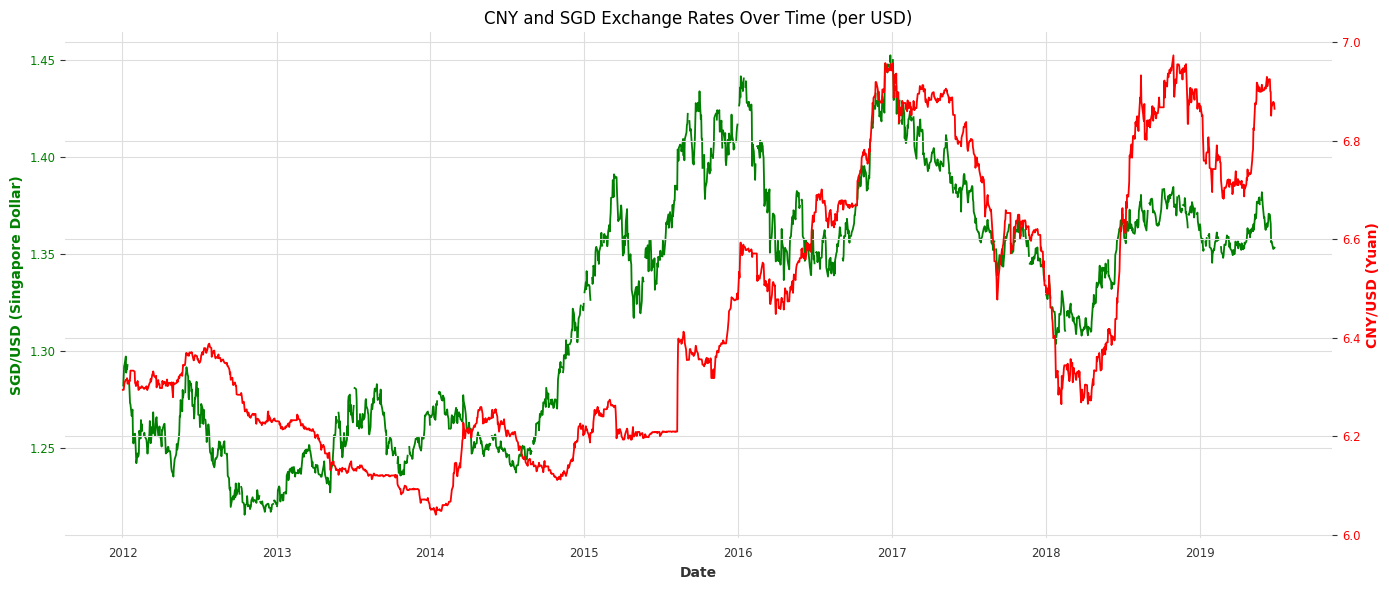

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color_sgd = 'green'
ax1.set_xlabel('Date')
ax1.set_ylabel('SGD/USD (Singapore Dollar)', color=color_sgd)
ax1.plot(df_eda.index, df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'], color=color_sgd, label='SGD/USD')
ax1.tick_params(axis='y', labelcolor=color_sgd)

ax2 = ax1.twinx()
color_cny = 'red'
ax2.set_ylabel('CNY/USD (Yuan)', color=color_cny)
ax2.plot(df_eda.index, df_eda['CHINA - YUAN/US$'], color=color_cny, label='CNY/USD')
ax2.tick_params(axis='y', labelcolor=color_cny)

plt.title('CNY and SGD Exchange Rates Over Time (per USD)')
fig.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'] = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()

sgd_monthly = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].asfreq('MS').interpolate(method='linear')
cny_monthly = df_eda['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

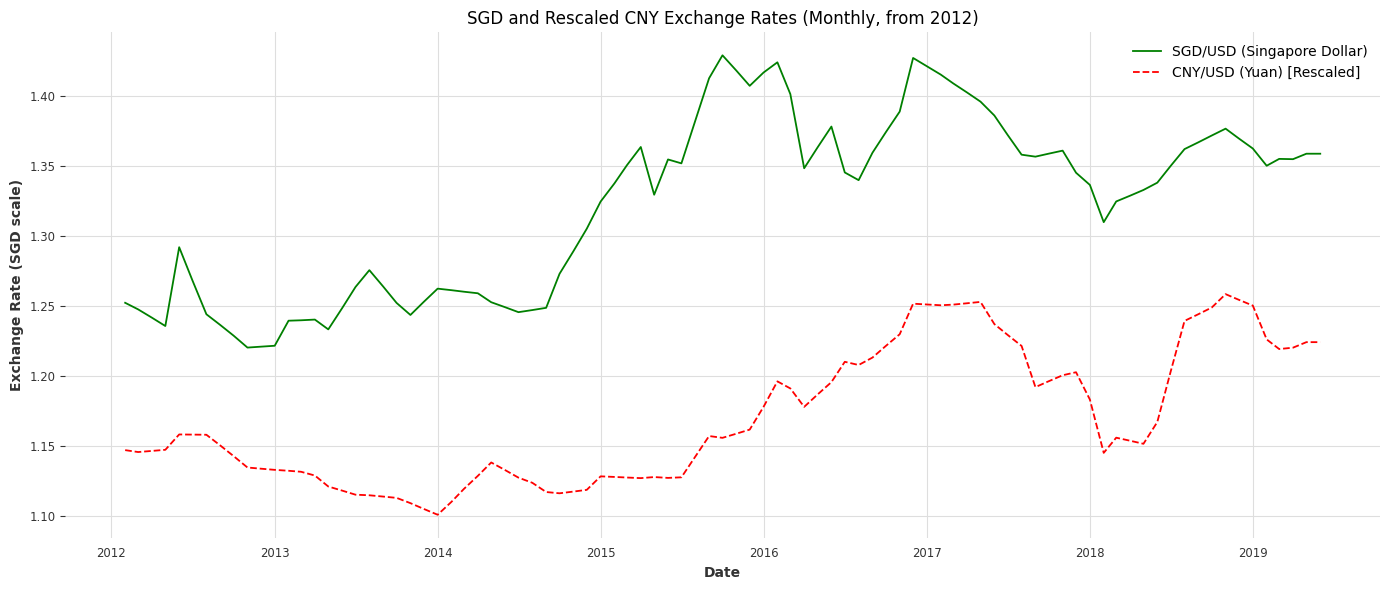

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(sgd_monthly.index, sgd_monthly, label='SGD/USD (Singapore Dollar)', color='green')
plt.plot(cny_monthly.index, cny_monthly / 5.5, label='CNY/USD (Yuan) [Rescaled]', color='red', linestyle='--')

plt.title('SGD and Rescaled CNY Exchange Rates (Monthly, from 2012)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (SGD scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

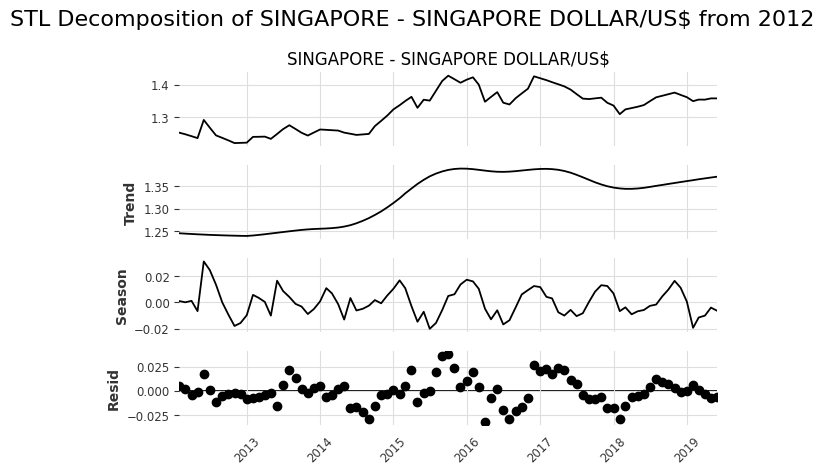

In [ ]:
df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'] = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()

df_eda_monthly = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].asfreq('MS').interpolate(method='linear')

if not df_eda_monthly.empty:
    stl = STL(df_eda_monthly, period=12)
    result = stl.fit()

    fig = result.plot()
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    plt.suptitle('STL Decomposition of SINGAPORE - SINGAPORE DOLLAR/US$ from 2012', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("df_kpi_monthly is empty. Cannot perform STL decomposition.")

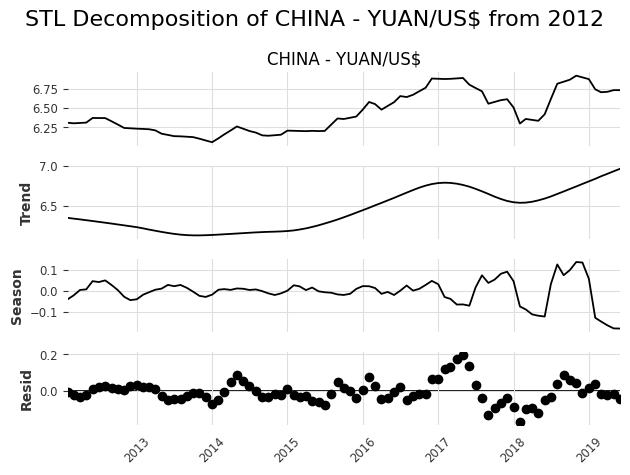

In [ ]:
df_eda['CHINA - YUAN/US$'] = df_eda['CHINA - YUAN/US$'].ffill().bfill()

df_eda_monthly = df_eda['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

if not df_eda_monthly.empty:
    stl = STL(df_eda_monthly, period=12)
    result = stl.fit()

    fig = result.plot()
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    plt.suptitle('STL Decomposition of CHINA - YUAN/US$ from 2012', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("df_kpi_monthly is empty. Cannot perform STL decomposition.")

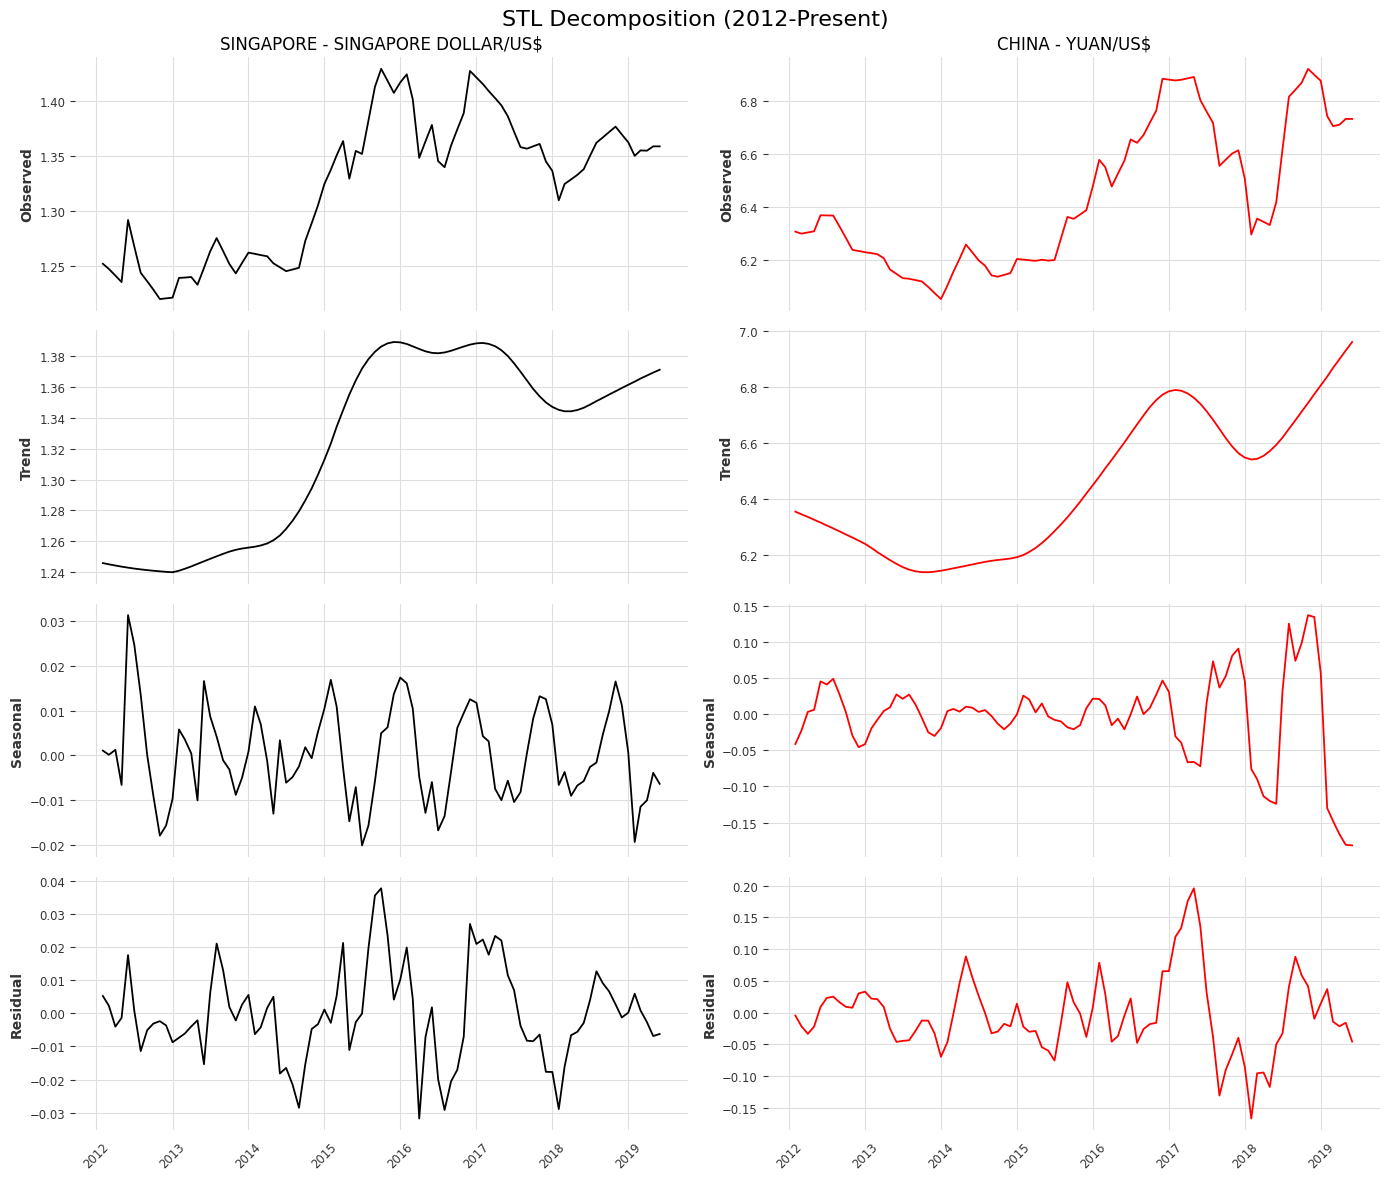

In [ ]:
df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'] = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()
df_eda['CHINA - YUAN/US$'] = df_eda['CHINA - YUAN/US$'].ffill().bfill()

sgd_monthly = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].asfreq('MS').interpolate(method='linear')
cny_monthly = df_eda['CHINA - YUAN/US$'].asfreq('MS').interpolate(method='linear')

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)

if not sgd_monthly.empty:
    stl_sgd = STL(sgd_monthly, period=12).fit()

    axes[0, 0].plot(stl_sgd.observed)
    axes[0, 0].set_ylabel('Observed')
    axes[1, 0].plot(stl_sgd.trend)
    axes[1, 0].set_ylabel('Trend')
    axes[2, 0].plot(stl_sgd.seasonal)
    axes[2, 0].set_ylabel('Seasonal')
    axes[3, 0].plot(stl_sgd.resid)
    axes[3, 0].set_ylabel('Residual')

    axes[0, 0].set_title('SINGAPORE - SINGAPORE DOLLAR/US$')
    for ax in axes[:, 0]:
        ax.tick_params(axis='x', rotation=45)
else:
    print("sgd_monthly is empty. Cannot perform STL decomposition.")

if not cny_monthly.empty:
    stl_cny = STL(cny_monthly, period=12).fit()

    axes[0, 1].plot(stl_cny.observed, color='red')
    axes[0, 1].set_ylabel('Observed')
    axes[1, 1].plot(stl_cny.trend, color='red')
    axes[1, 1].set_ylabel('Trend')
    axes[2, 1].plot(stl_cny.seasonal, color='red')
    axes[2, 1].set_ylabel('Seasonal')
    axes[3, 1].plot(stl_cny.resid, color='red')
    axes[3, 1].set_ylabel('Residual')


    axes[0, 1].set_title('CHINA - YUAN/US$')
    for ax in axes[:, 1]:
        ax.tick_params(axis='x', rotation=45)
else:
    print("cny_monthly is empty. Cannot perform STL decomposition.")

plt.suptitle('STL Decomposition (2012-Present)', fontsize=16)
plt.tight_layout()
plt.show()

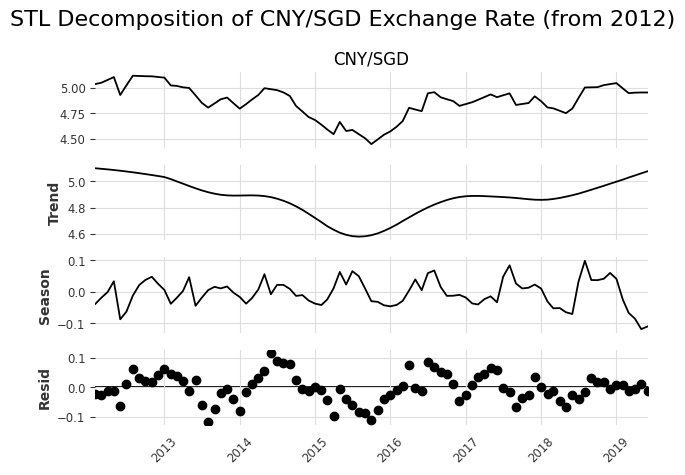

In [ ]:
df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'] = df_eda['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()
df_eda['CHINA - YUAN/US$'] = df_eda['CHINA - YUAN/US$'].ffill().bfill()

df_eda['CNY/SGD'] = df_eda['CHINA - YUAN/US$'] / df_eda['SINGAPORE - SINGAPORE DOLLAR/US$']

cny_sgd_monthly = df_eda['CNY/SGD'].asfreq('MS').interpolate(method='linear')

if not cny_sgd_monthly.empty:
    stl = STL(cny_sgd_monthly, period=12)
    result = stl.fit()

    fig = result.plot()
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    plt.suptitle('STL Decomposition of CNY/SGD Exchange Rate (from 2012)', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("cny_sgd_monthly is empty. Cannot perform STL decomposition.")

From the resulting graph of the seasonal decomposition of the PRC yuan versus the Singapore dollar, a clear seasonality pattern can be observed. Furthermore, the trend indicates that, starting from mid-2015, the market value of the yuan has exhibited significantly lower volatility. Therefore, I propose to construct a SARIMAX-based predictive model to forecast the market values of both currencies relative to the US dollar.

In [ ]:
df_eda_2015 = df_train_test[(df_train_test.index >= '2015-07-01') & (df_train_test.index < '2019-07-01')]
df_val = df_train_test[(df_train_test.index >= '2019-07-01') & (df_train_test.index < '2019-10-01')]
df_test = df_train_test[df_train_test.index >= '2019-10-01']

SARIMAX (like ARIMA) needs a continuous time series without missing data, and the index must be a DatetimeIndex.

In [ ]:
df_eda_2015.index = pd.to_datetime(df_eda_2015.index)

sgd_usd = df_eda_2015['SINGAPORE - SINGAPORE DOLLAR/US$']

sgd_usd = sgd_usd.ffill().bfill()

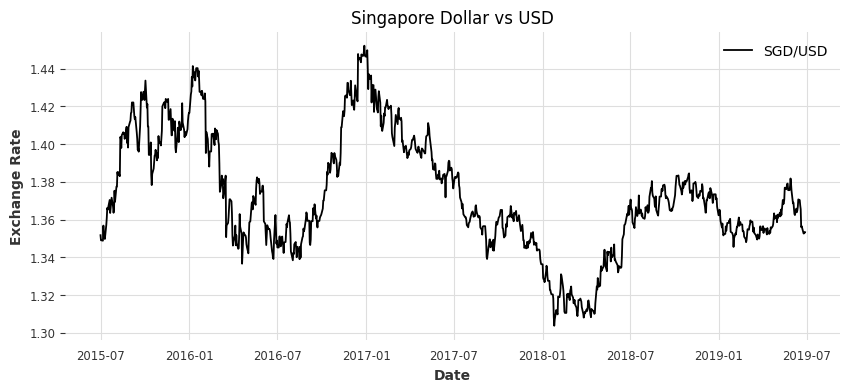

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(sgd_usd, label='SGD/USD')
plt.title('Singapore Dollar vs USD')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

SARIMAX/ARIMA models require a stationary series (constant mean & variance)

In [ ]:
result = adfuller(sgd_usd.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -2.2749021447962825
p-value: 0.18019032186198536


	•	If p-value < 0.05, the series is stationary.
	•	If p-value ≥ 0.05, we need differencing (parameter d > 0).

I need to difference the series (apply d=1) to remove trends and make it stationary

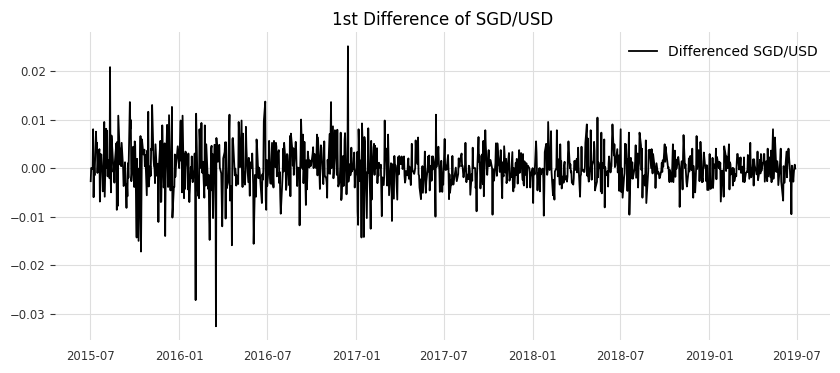

ADF Statistic: -33.99974547577667
p-value: 0.0


In [ ]:
sgd_usd_diff = sgd_usd.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(sgd_usd_diff, label='Differenced SGD/USD')
plt.title('1st Difference of SGD/USD')
plt.legend()
plt.show()

result_diff = adfuller(sgd_usd_diff)
print(f'ADF Statistic: {result_diff[0]}')
print(f'p-value: {result_diff[1]}')

Fit Initial SARIMAX Model

In [ ]:
# My training dataset is df_eda_2015['SINGAPORE - SINGAPORE DOLLAR/US$']
y_train = df_eda_2015['SINGAPORE - SINGAPORE DOLLAR/US$']

# Fit SARIMAX (start simple with (1,1,1))
model = SARIMAX(y_train, order=(1, 1, 1))
model_fit = model.fit(disp=False)

print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:     SINGAPORE - SINGAPORE DOLLAR/US$   No. Observations:                 1043
Model:                             SARIMAX(1, 1, 1)   Log Likelihood                3947.515
Date:                              Sun, 20 Jul 2025   AIC                          -7889.031
Time:                                      13:23:36   BIC                          -7874.184
Sample:                                  07-01-2015   HQIC                         -7883.399
                                       - 06-28-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5701      0.326     -1.746      0.081      -1.210       0.070
ma.L1          0.52

Validate on df_val

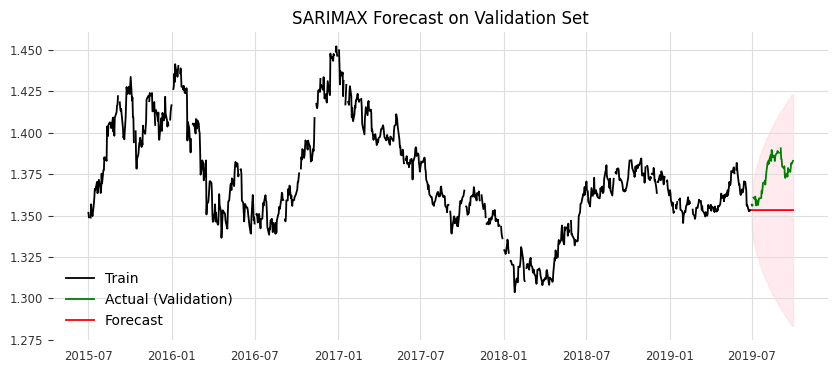

In [ ]:
pred_val = model_fit.get_forecast(steps=len(df_val))
pred_val_mean = pred_val.predicted_mean
pred_val_ci = pred_val.conf_int()

plt.figure(figsize=(10,4))
plt.plot(y_train, label='Train')
plt.plot(df_val.index, df_val['SINGAPORE - SINGAPORE DOLLAR/US$'], label='Actual (Validation)', color='green') # Added actual validation data
plt.plot(pred_val_mean, label='Forecast', color='red')
plt.fill_between(pred_val_ci.index, pred_val_ci.iloc[:, 0], pred_val_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title('SARIMAX Forecast on Validation Set')
plt.show()

Thus far, the resulting model has demonstrated rather limited predictive performance.

In [ ]:
y_train = df_eda_2015['SINGAPORE - SINGAPORE DOLLAR/US$']

# Seasonal SARIMAX model with annual seasonality
model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:     SINGAPORE - SINGAPORE DOLLAR/US$   No. Observations:                 1043
Model:               SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                3825.249
Date:                              Sun, 20 Jul 2025   AIC                          -7640.498
Time:                                      13:23:47   BIC                          -7615.880
Sample:                                  07-01-2015   HQIC                         -7631.148
                                       - 06-28-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5153      0.476     -1.082      0.279      -1.449       0.418
ma.L1          0.47

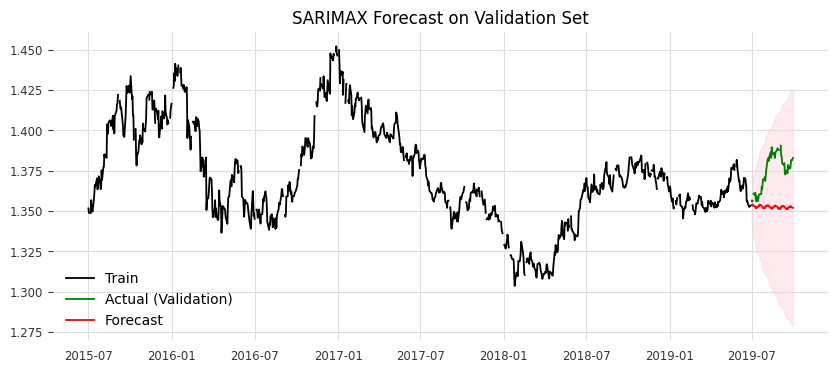

In [ ]:
pred_val = model_fit.get_forecast(steps=len(df_val))
pred_val_mean = pred_val.predicted_mean
pred_val_ci = pred_val.conf_int()

plt.figure(figsize=(10,4))
plt.plot(y_train, label='Train')
plt.plot(df_val.index, df_val['SINGAPORE - SINGAPORE DOLLAR/US$'], label='Actual (Validation)', color='green') # Added actual validation data
plt.plot(pred_val_mean, label='Forecast', color='red')
plt.fill_between(pred_val_ci.index, pred_val_ci.iloc[:, 0], pred_val_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title('SARIMAX Forecast on Validation Set')
plt.show()

Unfortunately, as the real market value of the Singapore dollar is more closely influenced by the value of the PRC yuan than by the US dollar, my approach of predicting the value of the PRC yuan through the market value of the Singapore dollar has proven unsuccessful. Consequently, it is necessary to explore alternative methodologies.

In [ ]:
# Target variable
y_train = df_eda_2015['SINGAPORE - SINGAPORE DOLLAR/US$']

# Exogenous variable
X_train = df_eda_2015[['CHINA - YUAN/US$']]  # Keep it as a DataFrame

# Check for and handle missing values in X_train
print("Missing values in X_train before handling:", X_train.isnull().sum())
X_train = X_train.ffill().bfill()
print("Missing values in X_train after handling:", X_train.isnull().sum())


# Build SARIMAX model
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),              # ARIMA terms (p,d,q)
    seasonal_order=(1, 1, 1, 12), # annual seasonality (12 months)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model
model_fit = model.fit(disp=False)
print(model_fit.summary())

Missing values in X_train before handling: CHINA - YUAN/US$    45
dtype: int64
Missing values in X_train after handling: CHINA - YUAN/US$    0
dtype: int64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:     SINGAPORE - SINGAPORE DOLLAR/US$   No. Observations:                 1043
Model:               SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                3929.340
Date:                              Sun, 20 Jul 2025   AIC                          -7846.680
Time:                                      13:23:57   BIC                          -7817.138
Sample:                                  07-01-2015   HQIC                         -7835.460
                                       - 06-28-2019                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
CHINA - YUAN/US$     0.1510      0.006     25.580      0.000       0.139       0.163
a

In [ ]:
X_forecast = df_test[['CHINA - YUAN/US$']]

# Check for and handle missing values in X_forecast
print("Missing values in X_forecast before handling:", X_forecast.isnull().sum())
X_forecast = X_forecast.ffill().bfill()
print("Missing values in X_forecast after handling:", X_forecast.isnull().sum())


forecast = model_fit.get_forecast(steps=len(df_test), exog=X_forecast)
y_pred = forecast.predicted_mean
forecast_ci = forecast.conf_int()

Missing values in X_forecast before handling: CHINA - YUAN/US$    4
dtype: int64
Missing values in X_forecast after handling: CHINA - YUAN/US$    0
dtype: int64


In [ ]:
y_train = df_eda_2015['SINGAPORE - SINGAPORE DOLLAR/US$'].ffill().bfill()


# Run auto_arima to find the best parameters
auto_model = auto_arima(
    y_train,
    exogenous=X_train, # Use the cleaned X_train
    seasonal=True,
    m=12,            # 12 months seasonality
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

# Fit SARIMAX with the best parameters
order = auto_model.order
seasonal_order = auto_model.seasonal_order

model = SARIMAX(y_train, exog=X_train, order=order, seasonal_order=seasonal_order)
model_fit = model.fit(disp=False)
print(model_fit.summary())

Performing stepwise search to minimize aic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-8278.539, Time=2.08 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-8287.720, Time=0.25 sec


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=-8287.159, Time=3.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 13.058 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1043
Model:               SARIMAX(0, 1, 0)   Log Likelihood                4145.860
Date:                Sun, 20 Jul 2025   AIC                          -8289.719
Time:                        13:24:10   BIC                          -8284.771
Sample:                    07-01-2015   HQIC                         -8287.842
                         - 06-28-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2.047e-05   4.62e-07     44.357      0.000    1.96e

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:     SINGAPORE - SINGAPORE DOLLAR/US$   No. Observations:                 1043
Model:                             SARIMAX(0, 1, 0)   Log Likelihood                4284.489
Date:                              Sun, 20 Jul 2025   AIC                          -8564.978
Time:                                      13:24:11   BIC                          -8555.080
Sample:                                  07-01-2015   HQIC                         -8561.223
                                       - 06-28-2019                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
CHINA - YUAN/US$     0.1391      0.006     21.773      0.000       0.127       0.152
s

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Key Observations
Model: SARIMAX(0, 1, 0)

This means there are no AR (p=0) or MA (q=0) terms — only differencing (d=1).

Essentially, it's like a random walk with exogenous variable (CNY/USD).

Exogenous variable (CHINA - YUAN/US$):

Coefficient = 0.1391 and p-value = 0.000 → Highly significant.

Interpretation: A 1 unit increase in CNY/USD is associated with a 0.1391 increase in SGD/USD (after differencing).

AIC = -8564.978

Lower AIC = better. This is quite a low value, which is good.

Ljung-Box test (L1): Prob(Q) = 0.00

Bad sign: The residuals may still have autocorrelation (model not fully capturing time dependencies).

You might need to add AR or MA terms (e.g., (p,d,q) ≠ (0,1,0)).

Jarque-Bera (JB): 1210.76 (Prob = 0.00)

Residuals are not normally distributed (skewed, heavy tails).

This can impact forecast confidence intervals.

Heteroskedasticity (H): 0.20 (Prob=0.00)

Residuals have changing variance (heteroskedasticity).

Could consider using GARCH models or transformations.

**ChatGPT - **

Use your CHINA - YUAN/US$ as an exogenous variable.

Search for the best (p,d,q)(P,D,Q,12) combination.

Show the best model and residual diagnostics.

**That is exactly what I have done in my previous model**